# Data Frame Combination

## Price volume data (basic df)

In [1]:
import pandas as pd 
import numpy as np
prices = pd.read_parquet("data/prices.parquet")
prices["date"] = pd.to_datetime(prices["date"]).dt.normalize()
prices["status"] = pd.to_numeric(prices["status"], errors="coerce")
prices.isna().sum()


ticker                 0
instrument_id          0
date                   0
open                   0
high                   0
low                    0
close                  0
adjusted_close         0
volume                 0
market_cap        185103
status                 0
updated                0
dtype: int64

### Status 0 rows are all Duplicated rows

In [2]:
prices["status"].value_counts(dropna=False)

status
1    7930541
0      69827
Name: count, dtype: int64

In [3]:
dup_mask = prices.duplicated(
    subset=["instrument_id", "date"],
    keep=False
)

dup_rows = prices.loc[dup_mask].copy()

dup_rows["status"].value_counts(dropna=False)

status
1    153022
0     69827
Name: count, dtype: int64

In [4]:
status0 = prices[prices["status"].eq(0)].copy()

status0_not_dup = status0[
    ~status0.set_index(["instrument_id", "date"]).index.isin(
        prices[prices.duplicated(["instrument_id", "date"], keep=False)]
        .set_index(["instrument_id", "date"])
        .index
    )
]

len(status0_not_dup)

0

### Drop dup

In [ ]:
dup_mask_clean = prices.duplicated(
    subset=["instrument_id", "date"],
    keep=False
)

dup_rows_clean = (
    prices
    .loc[dup_mask_clean]
    .sort_values(["instrument_id", "date", "ticker"])
)

dup_rows_clean.head(10)

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated
62,PARA,99,2000-01-03,1.8965,1.8965,1.7774,1.7793,2.2412,1762300.0,9.939995e+08,0,2025-11-04 11:20:12
61,PSKY,99,2000-01-03,1.8965,1.8965,1.7774,1.7793,2.2412,1762300.0,9.939995e+08,1,2025-11-04 20:40:50
985,PARA,99,2000-01-04,1.7657,1.7715,1.6758,1.6778,2.1133,1871300.0,9.372969e+08,0,2025-11-04 11:20:12
984,PSKY,99,2000-01-04,1.7657,1.7715,1.6758,1.6778,2.1133,1871300.0,9.372969e+08,1,2025-11-04 20:40:50
1903,PARA,99,2000-01-05,1.6817,1.6895,1.5938,1.6036,2.0198,2265200.0,8.958453e+08,0,2025-11-04 11:20:12
1902,PSKY,99,2000-01-05,1.6817,1.6895,1.5938,1.6036,2.0198,2265200.0,8.958453e+08,1,2025-11-04 20:40:50
2827,PARA,99,2000-01-06,1.5938,1.6055,1.5547,1.5977,2.0125,3235500.0,8.925493e+08,0,2025-11-04 11:20:12
2826,PSKY,99,2000-01-06,1.5938,1.6055,1.5547,1.5977,2.0125,3235500.0,8.925493e+08,1,2025-11-04 20:40:50
3748,PARA,99,2000-01-07,1.5938,1.6915,1.5860,1.6915,2.1306,2464800.0,9.449504e+08,0,2025-11-04 11:20:12
3747,PSKY,99,2000-01-07,1.5938,1.6915,1.5860,1.6915,2.1306,2464800.0,9.449504e+08,1,2025-11-04 20:40:50


In [6]:
key_cols = ["instrument_id", "date"]

non_key_cols = [c for c in dup_rows_clean.columns if c not in key_cols]

nunique_by_group = (
    dup_rows_clean
    .groupby(key_cols)[non_key_cols]
    .nunique(dropna=False)
)

cols_with_conflict = nunique_by_group.columns[
    (nunique_by_group > 1).any()
].tolist()

cols_with_conflict

['ticker', 'status', 'updated']

So we know that except "cols_with_conflict", other features has unique value for an unique ["instrument_id", "date"]

In [7]:
dup_before = prices.duplicated(subset=["instrument_id", "date"], keep=False).sum()
print("Duplicated instrument_id-date rows before cleaning:", dup_before)

prices_clean = (
    prices
    .sort_values(
        ["instrument_id", "date", "status"],
        ascending=[True, True, False]
    )
    .drop_duplicates(
        subset=["instrument_id", "date"],
        keep="first"
    )
    .copy()
)


max_rows_per_stock_date = (
    prices_clean
    .groupby(["instrument_id", "date"])
    .size()
    .max()
)

print("Max rows per instrument_id-date after cleaning:", max_rows_per_stock_date)

prices_clean = prices_clean.drop(columns='updated').copy()

prices_clean

Duplicated instrument_id-date rows before cleaning: 222849
Max rows per instrument_id-date after cleaning: 1


,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1
...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1


### Adjusted Factor
Using the adjusted close and the raw close to caculate adj factor

In [ ]:
prices_clean = prices_clean.sort_values(["instrument_id", "date"]).copy()

prices_clean["adj_factor"] = (
    prices_clean["adjusted_close"] / prices_clean["close"]
)

In [9]:
# Adjust OHLC
prices_clean["adjusted_open"] = prices_clean["open"] * prices_clean["adj_factor"]
prices_clean["adjusted_high"] = prices_clean["high"] * prices_clean["adj_factor"]
prices_clean["adjusted_low"] = prices_clean["low"] * prices_clean["adj_factor"]
prices_clean

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,adj_factor,adjusted_open,adjusted_high,adjusted_low
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1,1.939596,41.307375,42.509730,41.210395
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1,1.939597,42.645538,43.401787,41.792115
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1,1.939596,44.856262,50.325147,41.733900
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1,1.939592,41.908382,42.645427,41.850194
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1,1.939593,42.335100,43.013763,42.005369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1,1.000000,43.250000,43.830000,42.880000
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1,1.000000,42.970000,43.600000,42.680000
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1,1.000000,43.310000,43.530000,41.950000
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1,1.000000,42.730000,43.120000,41.775000


### Build Returns (target_c2o_next_adj is the expected return we will predict)

- For target_c2o_next_adj and target_c2c_adj, they cross days -> adjusted return
- For target_o2c_next_adj, the adjusted return will be the same as raw open -> close return

In [ ]:
prices_clean = prices_clean.sort_values(["instrument_id", "date"]).copy()

# Adjusted returns
prices_clean["target_c2o_next_adj"] = (
    prices_clean.groupby("instrument_id")["adjusted_open"].shift(-2)
    / prices_clean.groupby("instrument_id")["adjusted_close"].shift(-1)
    - 1
)

# 明日 open -> 明日 close
prices_clean["target_o2c_next_adj"] = (
    prices_clean.groupby("instrument_id")["adjusted_close"].shift(-1)
    / prices_clean.groupby("instrument_id")["adjusted_open"].shift(-1)
    - 1
)

# 今日 close -> 明日 close
prices_clean["target_c2c_adj"] = (
    prices_clean.groupby("instrument_id")["adjusted_close"].shift(-1)
    / prices_clean["adjusted_close"]
    - 1
)


# Drop rows without targets
target_cols = [
    "target_c2o_next_adj",
    "target_o2c_next_adj",
    "target_c2c_adj",
]

# prices_clean = prices_clean[
#     prices_clean[target_cols].notna().all(axis=1)
# ].copy()

prices_clean

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,adj_factor,adjusted_open,adjusted_high,adjusted_low,target_c2o_next_adj,target_o2c_next_adj,target_c2c_adj
3846661,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,41.6951,23716568.0,2.116608e+10,1,1.939596,41.307375,42.509730,41.210395,0.046608,0.004998,0.027907
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1,1.939597,42.645538,43.401787,41.792115,0.004181,-0.069608,-0.026244
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1,1.939596,44.856262,50.325147,41.733900,0.000917,0.009256,0.013476
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1,1.939592,41.908382,42.645427,41.850194,-0.003663,0.000000,0.000917
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1,1.939593,42.335100,43.013763,42.005369,0.009873,0.024367,0.020614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7993852,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,43.6100,49800.0,1.638719e+09,1,1.000000,43.250000,43.830000,42.880000,-0.005739,0.013731,-0.001147
7995479,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,43.5600,95500.0,1.636840e+09,1,1.000000,42.970000,43.600000,42.680000,-0.004891,-0.008543,-0.014233
7997108,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,42.9400,94400.0,1.613543e+09,1,1.000000,43.310000,43.530000,41.950000,0.006544,0.001404,-0.003493
7998737,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,42.7900,70900.0,1.607906e+09,1,1.000000,42.730000,43.120000,41.775000,NaN,-0.000697,0.005842


In [11]:
prices_clean.isna().sum()

ticker                      0
instrument_id               0
date                        0
open                        0
high                        0
low                         0
close                       0
adjusted_close              0
volume                      0
market_cap             179649
status                      0
adj_factor                  0
adjusted_open               0
adjusted_high               0
adjusted_low                0
target_c2o_next_adj      3212
target_o2c_next_adj      1607
target_c2c_adj           1607
dtype: int64

## cheapness_scores / gics_info

In [12]:
cheapness_scores = pd.read_parquet("data/cheapness_scores.parquet")
cheapness_scores['date'] = pd.to_datetime(cheapness_scores['date']).dt.normalize()

gics_info = pd.read_parquet("data/gics_info.parquet")
cheapness_scores.isna().sum()

instrument_id               0
date                        0
ticker                      0
gics_sector           2258868
gics_group            2258868
gics_industry         2258868
gics_subindustry      2258868
adjusted_close              0
market_cap                  0
valuation_score       2264928
quality_score         2259182
health_score          2263078
momentum_score        2261827
final_score           2270090
final_score_clean     2293111
score_velocity        2271681
score_acceleration    2273272
regime_break                0
value_trap                  0
dtype: int64

In [13]:
key_cols = ["instrument_id", "date"]

dup = cheapness_scores[
    cheapness_scores.duplicated(subset=key_cols, keep=False)
].copy()

non_key_cols = [c for c in cheapness_scores.columns if c not in key_cols]

dup_diff_summary = (
    dup
    .groupby(key_cols)[non_key_cols]
    .nunique(dropna=False)
)

cols_with_conflict = dup_diff_summary.columns[
    (dup_diff_summary > 1).any()
].tolist()

cols_with_conflict

['ticker', 'score_velocity', 'score_acceleration', 'regime_break']

 Same key_cols may have different ['ticker', 'score_velocity', 'score_acceleration', 'regime_break']

In [14]:
df = prices_clean.merge(
    cheapness_scores,
    how="left",
    left_on=["ticker", "instrument_id", "date"],
    right_on=["ticker", "instrument_id", "date"],
    validate="m:1",
)

df["market_cap"] = df["market_cap_x"].combine_first(df["market_cap_y"])
df["adjusted_close"] = df["adjusted_close_x"].combine_first(df["adjusted_close_y"])
df = df.drop(columns=["market_cap_x", "market_cap_y", "adjusted_close_x", "adjusted_close_y", 'score_velocity', 'score_acceleration', 'regime_break'])
df[['market_cap']] = (
    df
    .groupby("instrument_id")[['market_cap']]
    .ffill()
)
df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,gics_subindustry,valuation_score,quality_score,health_score,momentum_score,final_score,final_score_clean,value_trap,market_cap,adjusted_close
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.116608e+10,41.6951
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.175675e+10,42.8587
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.118577e+10,41.7339
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.147131e+10,42.2963
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2.149100e+10,42.3351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.638719e+09,43.6100
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.636840e+09,43.5600
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.613543e+09,42.9400
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.607906e+09,42.7900


### GICS is a snap shot -> Can be filled backward

In [15]:
# 使用 gics_info 靜態資料，補回 df 的 GICS 產業分類
# df 原本的 GICS 欄位名稱
old_gics_cols = ["gics_sector", "gics_group", "gics_industry", "gics_subindustry"]

# gics_info 裡面的 GICS 欄位名稱
gics_info_cols = ["sector", "industry_group", "industry", "subindustry"]

# 我們希望最後 df 裡面統一使用的欄位名稱
gics_rename_map = {
    "sector": "gics_sector",
    "industry_group": "gics_group",
    "industry": "gics_industry",
    "subindustry": "gics_subindustry",
}

#  gics_info 是靜態 mapping table，理論上一檔股票只能有一組 GICS
dup_gics = gics_info[gics_info.duplicated(subset=["instrument_id"], keep=False)]
print("Number of duplicated instrument_id in gics_info:", dup_gics["instrument_id"].nunique())

# 如果有重複，先保留最後一筆；正常情況應該不會有
gics_info_clean = (
    gics_info
    .drop_duplicates(subset=["instrument_id"], keep="last")
    [["instrument_id"] + gics_info_cols]
    .rename(columns=gics_rename_map)
)

# 刪掉 df 原本的 GICS 欄位
cols_to_drop = [col for col in old_gics_cols if col in df.columns]

df = df.drop(columns=cols_to_drop)
df = df.merge(
    gics_info_clean,
    on="instrument_id",
    how="left",
    validate="m:1",
)

print("Missing GICS after merging gics_info:")
print(df[old_gics_cols].isna().sum())

df

Number of duplicated instrument_id in gics_info: 0
Missing GICS after merging gics_info:
gics_sector         0
gics_group          0
gics_industry       0
gics_subindustry    0
dtype: int64


,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,momentum_score,final_score,final_score_clean,value_trap,market_cap,adjusted_close,gics_sector,gics_group,gics_industry,gics_subindustry
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,False,2.116608e+10,41.6951,25,2530,253010,25301020
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,False,2.175675e+10,42.8587,25,2530,253010,25301020
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,False,2.118577e+10,41.7339,25,2530,253010,25301020
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,False,2.147131e+10,42.2963,25,2530,253010,25301020
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,False,2.149100e+10,42.3351,25,2530,253010,25301020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.638719e+09,43.6100,45,4520,452020,45202030
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.636840e+09,43.5600,45,4520,452020,45202030
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.613543e+09,42.9400,45,4520,452020,45202030
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,NaN,NaN,NaN,1.607906e+09,42.7900,45,4520,452020,45202030


## Earnings Data

In [ ]:
earnings_calendar = pd.read_parquet("data/earnings_calendar.parquet")
earnings_transfo = pd.read_parquet("data/earnings_transfo.parquet")


# *** 要預測的 “預期return” 的時間線是 "t+1 close" 到 "t+2 open"

print(sum(earnings_calendar['reporting_date'].isna()))
print(sum(earnings_calendar['reporting_time'].isna()))
print(sum(earnings_calendar['before_after_market'].isna()))

# reporting_time全部都有值
# 給before_after_market是空值的附值，15:50為基準（依照作業說明）
# 若after -> 當作reporting_date的資料
# 若before -> reporting_date的前一天就可以有資料

earnings_calendar[earnings_calendar['before_after_market'].isna()]


0
0
823


,stock_id,reporting_date,strat_trading_date,reporting_time,before_after_market,period,period_end_date
137,4,2016-11-17,NaT,0 days 14:30:00,None,FY2017Q3,2016-10-29
155,4,2021-05-27,NaT,0 days 13:30:00,None,FY2022Q1,2021-05-01
194,5,2020-02-27,NaT,0 days 13:49:00,None,FY2019Q4,2019-12-31
262,6,2022-08-01,NaT,0 days 18:32:27,None,FY2022Q2,2022-06-30
326,7,2024-10-23,NaT,0 days 13:30:00,None,FY2024Q3,2024-09-30
...,...,...,...,...,...,...,...
60453,1588,2024-02-21,NaT,0 days 15:39:00,None,FY2023Q4,2023-12-30
60454,1588,2024-04-17,NaT,0 days 14:17:00,None,FY2024Q1,2024-03-30
60455,1588,2024-07-17,NaT,0 days 15:12:00,None,FY2024Q2,2024-06-29
60456,1588,2024-10-16,NaT,0 days 15:23:00,None,FY2024Q3,2024-09-28


### Merge df

For the announcement time < 15:50 -> set as "before"

In [17]:
earnings_transfo["date"] = pd.to_datetime(
    earnings_transfo["date"]
).dt.normalize()

earnings_calendar["reporting_date"] = pd.to_datetime(
    earnings_calendar["reporting_date"]
).dt.normalize()

# Fill missing before_after_market using 15:50 cutoff
cutoff = pd.Timedelta(hours=15, minutes=50)

mask_missing = earnings_calendar["before_after_market"].isna()

earnings_calendar.loc[mask_missing, "before_after_market"] = np.where(
    earnings_calendar.loc[mask_missing, "reporting_time"] < cutoff,
    "before",
    "after",
)

#  Merge before/after flag onto earnings_transfo
earnings_aligned = earnings_transfo.merge(
    earnings_calendar[['stock_id', 'reporting_date', 'before_after_market']],
    how="left",
    left_on=["stock_id", "date"],
    right_on=["stock_id", "reporting_date"],
    validate="m:1",
).drop(columns='reporting_date')

df = df.merge(
    earnings_aligned,
    how="left",
    left_on=["instrument_id", "date"],
    right_on=["stock_id", "date"],
    validate="m:1"
    ).drop(columns='stock_id')
df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,repsf4,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003897,-0.025200,0.05,0.00103,NaN
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003869,-0.025172,0.05,0.00103,NaN
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003520,-0.024823,0.05,0.00103,NaN
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,NaN,1.0,0.0,NaN,-0.003433,-0.024736,0.05,0.00103,NaN


### before vs after
For columns whose value is not changing daily, if the announcement time is "before" -> t-1 can already get the info, since the target of t-1 is t close to t+1 open

In [ ]:
# Build stock-level previous trading date
stock_dates = (
    df[["instrument_id", "date"]]
    .drop_duplicates()
    .sort_values(["instrument_id", "date"])
)

stock_dates["prev_date"] = (
    stock_dates.groupby("instrument_id")["date"].shift(1)
)

df = df.merge(
    stock_dates[["instrument_id", "date", "prev_date"]],
    how="left",
    on=["instrument_id", "date"],
    validate="m:1",
)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-12
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-13
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-16
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27


In [ ]:
df[df['instrument_id']==1612][-40:-34][['instrument_id', 'date'] + ['epsp', 'epsf', 'reps1', 'repsf4', 'sue', 'inesp',
       'inesn', 'reps41', 'repsfs', 'repsfl', 'nspc5', 'deps',
       'before_after_market', 'prev_date']]


,instrument_id,date,epsp,epsf,reps1,repsf4,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date
7883190,1612,2024-11-04,NaN,0.024283,NaN,NaN,NaN,0.0,1.0,NaN,-0.007163,-0.018199,0.00,0.00112,NaN,2024-11-01
7883191,1612,2024-11-05,NaN,0.023590,NaN,NaN,NaN,0.0,1.0,NaN,-0.007857,-0.018892,0.00,0.00112,NaN,2024-11-04
7883192,1612,2024-11-06,NaN,0.022843,NaN,NaN,NaN,0.0,1.0,NaN,-0.008604,-0.019639,0.00,0.00112,NaN,2024-11-05
7883193,1612,2024-11-07,0.012779,0.028101,-0.015339,-0.171313,-0.621133,0.0,1.0,-0.139207,0.000000,-0.021303,0.00,-0.01003,before,2024-11-06
7883194,1612,2024-11-08,NaN,0.025713,NaN,NaN,NaN,1.0,0.0,NaN,-0.002388,-0.023691,0.05,0.00103,NaN,2024-11-07
7883195,1612,2024-11-11,NaN,0.026179,NaN,NaN,NaN,1.0,0.0,NaN,-0.001922,-0.023225,0.05,0.00103,NaN,2024-11-08


In [19]:
# Define columns to copy from before-market event to previous date
copy_cols = [
    "epsp",
    "reps1",
    "repsf4",
    "sue",
    "reps41",
]
# -----------------------------
# 7. Extract before-market rows and move their features to prev_date
# -----------------------------
before_mask = (
    df["before_after_market"].eq("before")
    & df["prev_date"].notna()
)

before_to_prev = df.loc[
    before_mask,
    ["instrument_id", "prev_date"] + copy_cols
].copy()

# prev_date becomes the date to be updated
before_to_prev = before_to_prev.rename(columns={"prev_date": "date"})

# If multiple before events map to same stock-date, keep last
before_to_prev = before_to_prev.drop_duplicates(
    subset=["instrument_id", "date"],
    keep="last",
)

# -----------------------------
# 8. Merge moved values back to original table
# -----------------------------
df = df.merge(
    before_to_prev,
    how="left",
    on=["instrument_id", "date"],
    suffixes=("", "_from_before"),
    validate="m:1",
)

# -----------------------------
# 9. Fill only NaN values using copied before-market features
# -----------------------------
for col in copy_cols:
    moved_col = col + "_from_before"
    if moved_col in df.columns:
        df[col] = df[col].combine_first(
            df[moved_col]
        )
        df = df.drop(columns=moved_col)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-12
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-13
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-16
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,NaN,1.0,0.0,NaN,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27


In [20]:
df = df.sort_values(["instrument_id", "date"]).copy()

# initialize
df["earn_effective_date"] = pd.NaT

# before-market: move effective date to previous trading date
mask_before = (
    df["before_after_market"].eq("before")
    & df["prev_date"].notna()
)

df.loc[mask_before, "earn_effective_date"] = df.loc[
    mask_before, "prev_date"
]

# after-market: effective date stays on reporting date
mask_after = df["before_after_market"].eq("after")

df.loc[mask_after, "earn_effective_date"] = df.loc[
    mask_after, "date"
]

df["earn_effective_date"] = pd.to_datetime(df["earn_effective_date"])

In [21]:
# row t is implemented at close of t+1
df["trade_date"] = df.groupby("instrument_id")["date"].shift(-1)

earn_events = (
    df.loc[df["earn_effective_date"].notna(), ["instrument_id", "earn_effective_date"]]
    .drop_duplicates()
)

window_rows = []

for offset in [-2, -1, 0, 1, 2]:
    tmp = earn_events.copy()
    tmp["trade_date"] = tmp.groupby("instrument_id")["earn_effective_date"].transform(
        lambda x: x
    )
    tmp["trade_date"] = tmp["earn_effective_date"] + pd.offsets.BDay(offset)
    window_rows.append(tmp[["instrument_id", "trade_date"]])

earn_window = pd.concat(window_rows, ignore_index=True).drop_duplicates()
earn_window["in_earn_window"] = True

df = df.merge(
    earn_window,
    how="left",
    on=["instrument_id", "trade_date"],
    validate="m:1",
)

df["in_earn_window"] = df["in_earn_window"].fillna(False)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_1944/2327318679.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["in_earn_window"] = df["in_earn_window"].fillna(False)


In [22]:
# 完成：若before -> 將該日資料填寫至reporting_date前一天的空值部分

df[df['before_after_market']=="before"]
df[df['instrument_id']==1612][-40:-34][['instrument_id', 'date', 'before_after_market'] + copy_cols]


,instrument_id,date,before_after_market,epsp,reps1,repsf4,sue,reps41
7883190,1612,2024-11-04,NaN,NaN,NaN,NaN,NaN,NaN
7883191,1612,2024-11-05,NaN,NaN,NaN,NaN,NaN,NaN
7883192,1612,2024-11-06,NaN,0.012779,-0.015339,-0.171313,-0.621133,-0.139207
7883193,1612,2024-11-07,before,0.012779,-0.015339,-0.171313,-0.621133,-0.139207
7883194,1612,2024-11-08,NaN,NaN,NaN,NaN,NaN,NaN
7883195,1612,2024-11-11,NaN,NaN,NaN,NaN,NaN,NaN


### Forward fill

In [23]:
# 對 earnings features 做 forward fill
# 前提：
# 1. before-market earnings 已經被複製到前一個 trading date
# 2. after-market earnings 留在 reporting_date
# 3. 所以現在只允許往後填充，不允許往前補

df = df.sort_values(["instrument_id", "date"]).copy()

# 這些是可以往後延續的 earnings / analyst revision 特徵
earn_feature_cols = [
    "epsp",
    "epsf",
    "reps1",
    "repsf4",
    "sue",
    "inesp",
    "inesn",
    "reps41",
    "repsfs",
    "repsfl",
    "nspc5",
    "deps",
]

# 在每一檔股票內部，依日期往後填充
df[earn_feature_cols] = (
    df
    .groupby("instrument_id")[earn_feature_cols]
    .ffill()
)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,reps41,repsfs,repsfl,nspc5,deps,before_after_market,prev_date,earn_effective_date,trade_date,in_earn_window
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,2013-12-13,False
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-12,NaT,2013-12-16,False
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-13,NaT,2013-12-17,False
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-16,NaT,2013-12-18,False
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,NaN,2013-12-17,NaT,2013-12-19,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,-0.139207,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23,NaT,2024-12-26,False
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,-0.139207,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24,NaT,2024-12-27,False
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,-0.139207,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26,NaT,2024-12-30,False
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,-0.139207,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27,NaT,2024-12-31,False


In [ ]:
# 完成：若before -> 將該日資料填寫至reporting_date前一天的空值部分

df[df['before_after_market']=="before"]
df[df['instrument_id']==1612][-40:-34][['instrument_id', 'date', 'before_after_market'] + earn_feature_cols]


,instrument_id,date,before_after_market,epsp,epsf,reps1,repsf4,sue,inesp,inesn,reps41,repsfs,repsfl,nspc5,deps
7883190,1612,2024-11-04,NaN,0.028117,0.024283,-0.006355,NaN,0.044249,0.0,1.0,-0.000290,-0.007163,-0.018199,0.00,0.00112
7883191,1612,2024-11-05,NaN,0.028117,0.023590,-0.006355,NaN,0.044249,0.0,1.0,-0.000290,-0.007857,-0.018892,0.00,0.00112
7883192,1612,2024-11-06,NaN,0.012779,0.022843,-0.015339,-0.171313,-0.621133,0.0,1.0,-0.139207,-0.008604,-0.019639,0.00,0.00112
7883193,1612,2024-11-07,before,0.012779,0.028101,-0.015339,-0.171313,-0.621133,0.0,1.0,-0.139207,0.000000,-0.021303,0.00,-0.01003
7883194,1612,2024-11-08,NaN,0.012779,0.025713,-0.015339,-0.171313,-0.621133,1.0,0.0,-0.139207,-0.002388,-0.023691,0.05,0.00103
7883195,1612,2024-11-11,NaN,0.012779,0.026179,-0.015339,-0.171313,-0.621133,1.0,0.0,-0.139207,-0.001922,-0.023225,0.05,0.00103


In [24]:
df.columns

Index(['ticker', 'instrument_id', 'date', 'open', 'high', 'low', 'close',
       'volume', 'status', 'adj_factor', 'adjusted_open', 'adjusted_high',
       'adjusted_low', 'target_c2o_next_adj', 'target_o2c_next_adj',
       'target_c2c_adj', 'valuation_score', 'quality_score', 'health_score',
       'momentum_score', 'final_score', 'final_score_clean', 'value_trap',
       'market_cap', 'adjusted_close', 'gics_sector', 'gics_group',
       'gics_industry', 'gics_subindustry', 'epsp', 'epsf', 'reps1', 'repsf4',
       'sue', 'inesp', 'inesn', 'reps41', 'repsfs', 'repsfl', 'nspc5', 'deps',
       'before_after_market', 'prev_date', 'earn_effective_date', 'trade_date',
       'in_earn_window'],
      dtype='object')

In [ ]:
df = df.drop(columns=['before_after_market', 'prev_date'])

## piotrosky

In [25]:
piotrosky = pd.read_parquet('data/piotrosky.parquet')
print(piotrosky.isna().sum())
piotrosky

stock_id          0
reporting_date    0
piot              0
piot_feat_nb      0
piot_norm         0
dtype: int64


,stock_id,reporting_date,piot,piot_feat_nb,piot_norm
0,1,2010-02-14,0,1,0.000000
1,1,2011-02-14,1,1,1.000000
2,1,2012-02-14,2,2,1.000000
3,1,2013-10-18,5,6,0.833333
4,1,2014-02-27,7,8,0.875000
...,...,...,...,...,...
33031,1612,2020-02-11,5,8,0.625000
33032,1612,2021-02-10,4,8,0.500000
33033,1612,2022-02-10,6,8,0.750000
33034,1612,2023-02-09,2,8,0.250000


### Merge df, forward fill

In [26]:
df = df.merge(
    piotrosky[['stock_id', 'reporting_date', 'piot_norm']],
    how="left",
    left_on=["instrument_id", "date"],
    right_on=["stock_id", "reporting_date"],
    validate="m:1"
    ).drop(columns=['stock_id', 'reporting_date'])


# 在每一檔股票內部，依日期往後填充
df[['piot_norm']] = (
    df
    .groupby("instrument_id")[['piot_norm']]
    .ffill()
)

df

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,repsfs,repsfl,nspc5,deps,before_after_market,prev_date,earn_effective_date,trade_date,in_earn_window,piot_norm
0,HLT,1,2013-12-12,21.2969,21.9168,21.2469,21.4968,23716568.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,NaT,NaT,2013-12-13,False,NaN
1,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,3984417.0,1,1.939597,...,NaN,NaN,NaN,NaN,NaN,2013-12-12,NaT,2013-12-16,False,NaN
2,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,3226908.0,1,1.939596,...,NaN,NaN,NaN,NaN,NaN,2013-12-13,NaT,2013-12-17,False,NaN
3,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,1584449.0,1,1.939592,...,NaN,NaN,NaN,NaN,NaN,2013-12-16,NaT,2013-12-18,False,NaN
4,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,1955194.0,1,1.939593,...,NaN,NaN,NaN,NaN,NaN,2013-12-17,NaT,2013-12-19,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7883225,DBD,1612,2024-12-24,43.2500,43.8300,42.8800,43.6100,49800.0,1,1.000000,...,-0.003897,-0.025200,0.05,0.00103,NaN,2024-12-23,NaT,2024-12-26,False,0.625
7883226,DBD,1612,2024-12-26,42.9700,43.6000,42.6800,43.5600,95500.0,1,1.000000,...,-0.003869,-0.025172,0.05,0.00103,NaN,2024-12-24,NaT,2024-12-27,False,0.625
7883227,DBD,1612,2024-12-27,43.3100,43.5300,41.9500,42.9400,94400.0,1,1.000000,...,-0.003520,-0.024823,0.05,0.00103,NaN,2024-12-26,NaT,2024-12-30,False,0.625
7883228,DBD,1612,2024-12-30,42.7300,43.1200,41.7750,42.7900,70900.0,1,1.000000,...,-0.003433,-0.024736,0.05,0.00103,NaN,2024-12-27,NaT,2024-12-31,False,0.625


In [27]:
df.isna().sum()

ticker                       0
instrument_id                0
date                         0
open                         0
high                         0
low                          0
close                        0
volume                       0
status                       0
adj_factor                   0
adjusted_open                0
adjusted_high                0
adjusted_low                 0
target_c2o_next_adj       3212
target_o2c_next_adj       1607
target_c2c_adj            1607
valuation_score        4123885
quality_score          4118168
health_score           4121901
momentum_score         4120813
final_score            4128913
final_score_clean      4151934
value_trap             1891334
market_cap              173664
adjusted_close               0
gics_sector                  0
gics_group                   0
gics_industry                0
gics_subindustry             0
epsp                   3737337
epsf                   4024012
reps1                  3828120
repsf4  

## short_interest_transfo

In [28]:
short_interest_transfo = pd.read_parquet('data/short_interest_transfo.parquet')
print(short_interest_transfo.isna().sum())

dup_check = (
    short_interest_transfo
    .groupby(["stock_id", "date"])
    .size()
    .reset_index(name="n")
    .query("n > 1")
    .sort_values("n", ascending=False)
)
dup_check

stock_id    0
date        0
dsi         0
dtcn        0
ddtcn       0
dtype: int64


,stock_id,date,n


### Merge df
As the short-interest information is released with a delay, I apply a conservative availability lag by shifting each short-interest observation forward by 10 calendar days. I then outer-merge the shifted short-interest data with the daily OHLCV panel, forward-fill the short-interest variables within each stock, and finally remove rows without valid price-volume observations. This outer-merge step is necessary because D+10 calendar days may not be a trading day, so the value has to be introduced on the lagged calendar date and then carried forward to the next valid trading row.

In [29]:
short_cols = ["dsi", "dtcn", "ddtcn"]

# -----------------------------
# 1. Prepare short-interest data
# -----------------------------
si = short_interest_transfo.copy()
si["date"] = pd.to_datetime(si["date"]).dt.normalize()

# snapshot date D becomes available after 10 calendar days
si["date"] = si["date"] + pd.Timedelta(days=10)

si = (
    si[["stock_id", "date"] + short_cols]
    .rename(columns={"stock_id": "instrument_id"})
    .drop_duplicates(subset=["instrument_id", "date"], keep="last")
)

# -----------------------------
# 2. Prepare main OHLCV panel
# -----------------------------
panel = df.copy()
panel["date"] = pd.to_datetime(panel["date"]).dt.normalize()

# mark original OHLCV rows, so we can remove artificial rows later
panel["_is_ohlcv_row"] = True

# -----------------------------
# 3. Outer merge short-interest availability dates into panel
# -----------------------------
df = panel.merge(
    si,
    how="outer",
    on=["instrument_id", "date"],
    validate="m:1"
)

# rows coming only from short-interest dates are not OHLCV rows
df["_is_ohlcv_row"] = df["_is_ohlcv_row"].fillna(False)

# -----------------------------
# 4. Sort and forward-fill within each stock
# -----------------------------
df = df.sort_values(["instrument_id", "date"]).copy()

df[short_cols] = (
    df
    .groupby("instrument_id")[short_cols]
    .ffill()
)

# -----------------------------
# 5. Keep only original OHLCV trading rows
# -----------------------------
df = (
    df[df["_is_ohlcv_row"]]
    .drop(columns="_is_ohlcv_row")
    .sort_values(["instrument_id", "date"])
    .reset_index(drop=True)
)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_1944/3720755083.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["_is_ohlcv_row"] = df["_is_ohlcv_row"].fillna(False)


### NVDA example

Representative ticker: NVDA
             date ticker       dsi      dtcn     ddtcn
423911 2002-08-05   NVDA  0.087315  1.116913 -1.093084
423912 2002-08-06   NVDA  0.087315  1.116913 -1.093084
423913 2002-08-07   NVDA  0.087315  1.116913 -1.093084
423914 2002-08-08   NVDA  0.087315  1.116913 -1.093084
423915 2002-08-09   NVDA  0.087315  1.116913 -1.093084
             date ticker       dsi      dtcn     ddtcn
429547 2024-12-24   NVDA  0.010783  1.400001  0.796458
429548 2024-12-26   NVDA  0.010783  1.400001  0.796458
429549 2024-12-27   NVDA  0.010783  1.400001  0.796458
429550 2024-12-30   NVDA  0.010783  1.400001  0.796458
429551 2024-12-31   NVDA  0.010783  1.400001  0.796458


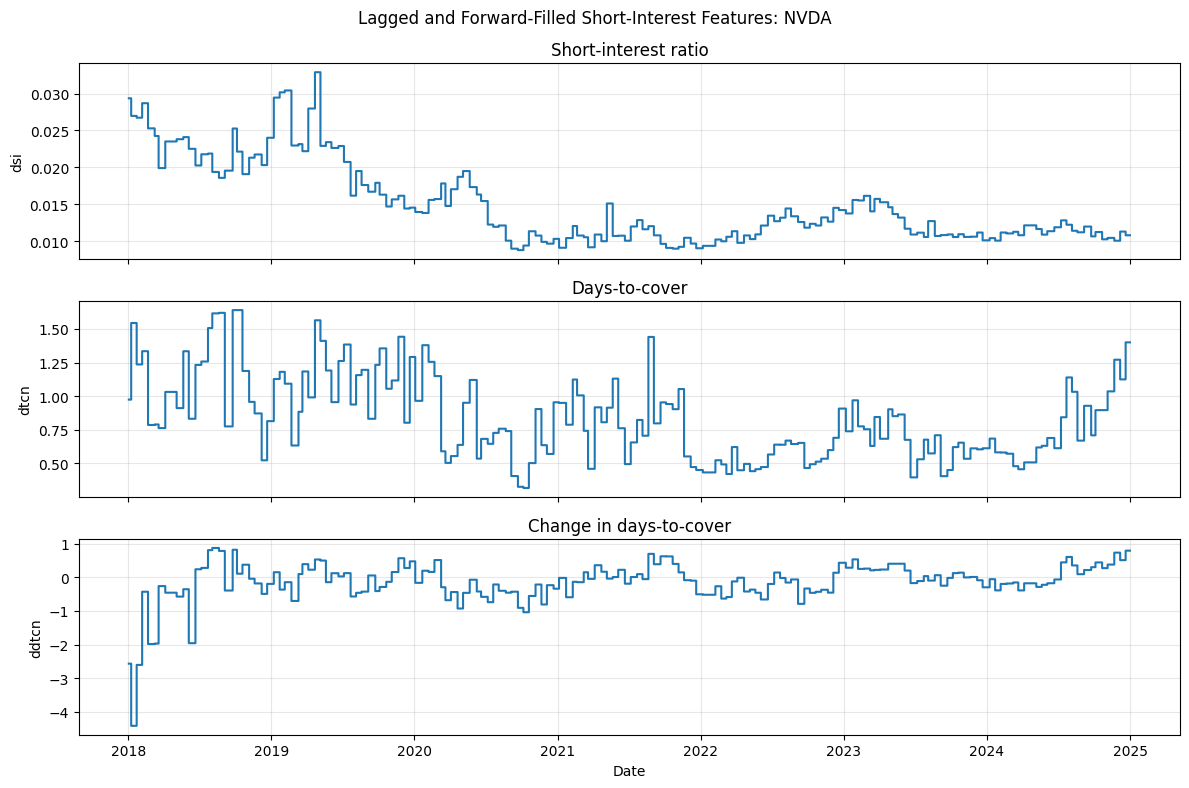

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Choose representative stock
# -----------------------------
plot_df = df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

# 如果你知道要畫哪一檔，直接指定
REP_TICKER = "NVDA"   # 可以改成 "TSLA", "GME", "MSFT" 等

rep = (
    plot_df.loc[plot_df["ticker"].eq(REP_TICKER),
                ["date", "ticker", "dsi", "dtcn", "ddtcn"]]
    .sort_values("date")
    .dropna(subset=["dsi", "dtcn", "ddtcn"], how="all")
)

# 如果指定 ticker 沒資料，自動挑一檔 short-interest 資料最多的股票
if rep.empty:
    counts = (
        plot_df.dropna(subset=["dsi", "dtcn", "ddtcn"], how="all")
        .groupby("ticker")
        .size()
        .sort_values(ascending=False)
    )
    REP_TICKER = counts.index[0]
    rep = (
        plot_df.loc[plot_df["ticker"].eq(REP_TICKER),
                    ["date", "ticker", "dsi", "dtcn", "ddtcn"]]
        .sort_values("date")
        .dropna(subset=["dsi", "dtcn", "ddtcn"], how="all")
    )

print("Representative ticker:", REP_TICKER)
print(rep.head())
print(rep.tail())

# -----------------------------
# Optional: restrict plot window
# -----------------------------
rep_plot = rep[
    (rep["date"] >= "2018-01-01") &
    (rep["date"] <= "2024-12-31")
].copy()

# -----------------------------
# Plot dsi
# -----------------------------
os.makedirs("figures", exist_ok=True)

cols = [
    ("dsi", "Short-interest ratio"),
    ("dtcn", "Days-to-cover"),
    ("ddtcn", "Change in days-to-cover"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (col, title) in zip(axes, cols):
    ax.step(rep_plot["date"], rep_plot[col], where="post")
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Lagged and Forward-Filled Short-Interest Features: {REP_TICKER}", y=0.98)
plt.tight_layout()
plt.savefig("figures/short_interest_representative.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
df.isna().sum()

ticker                       0
instrument_id                0
date                         0
open                         0
high                         0
low                          0
close                        0
volume                       0
status                       0
adj_factor                   0
adjusted_open                0
adjusted_high                0
adjusted_low                 0
target_c2o_next_adj       3212
target_o2c_next_adj       1607
target_c2c_adj            1607
valuation_score        4123885
quality_score          4118168
health_score           4121901
momentum_score         4120813
final_score            4128913
final_score_clean      4151934
value_trap             1891334
market_cap              173664
adjusted_close               0
gics_sector                  0
gics_group                   0
gics_industry                0
gics_subindustry             0
epsp                   3737337
epsf                   4024012
reps1                  3828120
repsf4  

### S&P

### 沒有用

In [44]:
# sp400_constituents = pd.read_parquet('data/sp400_constituents.parquet')
# sp500_constituents = pd.read_parquet('data/sp500_constituents.parquet')
# sp500 = pd.read_parquet('data/sp500_tr.parquet')

# Filtering the universe
Over 12 months trading history + Large market cap

In [32]:
def build_yearly_eligible_dict(
    df: pd.DataFrame,
    start_year: int = 2010,
    end_year: int = 2024,
    top_n: int = 1000,
) -> tuple[dict[int, list[int]], pd.DataFrame]:

    data = df.copy()
    data["year"] = data["date"].dt.year

    eligible_dict = {}
    eligible_tables = []

    for year in range(start_year, end_year + 1):
        asof_year = year - 1
        year_dates = data.loc[data["year"].eq(asof_year), "date"]
        if year_dates.empty:
            print(f"[Warning] No data for asof_year={asof_year}; universe_year={year} empty")
            eligible_dict[year] = []
            continue
        first_trading_date = year_dates.min()
        last_trading_date = year_dates.max()

        first_day_ids = set(
            data.loc[
                data["date"].eq(first_trading_date),
                "instrument_id"
            ].astype(int)
        )

        snapshot = data.loc[data["date"].eq(last_trading_date)].copy()

        # 只保留主要 ticker / valid row
        # 必須在前一年第一個交易日就存在
        snapshot = snapshot.loc[
            snapshot["instrument_id"].astype(int).isin(first_day_ids)
        ].copy()

        # market_cap 必須存在
        snapshot = snapshot.loc[snapshot["market_cap"].notna()].copy()

        # 取市值前 top_n
        selected = (
            snapshot
            .sort_values("market_cap", ascending=False)
            .head(top_n)
            .copy()
        )

        selected["universe_year"] = year
        selected["asof_year"] = asof_year
        selected["first_trading_date_prev_year"] = first_trading_date
        selected["asof_date"] = last_trading_date
        selected["rank_mcap"] = np.arange(1, len(selected) + 1)

        eligible_dict[year] = selected["instrument_id"].astype(int).tolist()

        eligible_tables.append(
            selected[
                [
                    "universe_year",
                    "asof_year",
                    "first_trading_date_prev_year",
                    "asof_date",
                    "instrument_id",
                    "ticker",
                    "market_cap",
                    "rank_mcap",
                ]
            ].copy()
        )

        print(
            f"Universe {year}: "
            f"prev_year_first_date={first_trading_date.date()}, "
            f"asof_date={last_trading_date.date()}, "
            f"n_selected={len(selected)}"
        )

    eligible_table = pd.concat(eligible_tables, ignore_index=True)

    return eligible_dict, eligible_table


eligible_dict, eligible_table = build_yearly_eligible_dict(
    df,
    start_year=2010,
    end_year=2024,
    top_n=1000,
)

Universe 2010: prev_year_first_date=2009-01-02, asof_date=2009-12-31, n_selected=1000
Universe 2011: prev_year_first_date=2010-01-04, asof_date=2010-12-31, n_selected=1000
Universe 2012: prev_year_first_date=2011-01-03, asof_date=2011-12-30, n_selected=1000
Universe 2013: prev_year_first_date=2012-01-03, asof_date=2012-12-31, n_selected=1000
Universe 2014: prev_year_first_date=2013-01-02, asof_date=2013-12-31, n_selected=1000
Universe 2015: prev_year_first_date=2014-01-02, asof_date=2014-12-31, n_selected=1000
Universe 2016: prev_year_first_date=2015-01-02, asof_date=2015-12-31, n_selected=1000
Universe 2017: prev_year_first_date=2016-01-04, asof_date=2016-12-30, n_selected=1000
Universe 2018: prev_year_first_date=2017-01-03, asof_date=2017-12-29, n_selected=1000
Universe 2019: prev_year_first_date=2018-01-02, asof_date=2018-12-31, n_selected=1000
Universe 2020: prev_year_first_date=2019-01-02, asof_date=2019-12-31, n_selected=1000
Universe 2021: prev_year_first_date=2020-01-02, asof_d

### Save the Basic Universe

In [34]:
import pickle

with open("data/eligible_dict.pkl", "wb") as f:
    pickle.dump(eligible_dict, f)

### Check evolution in the universe year

In [36]:
def summarize_yearly_universe_evolution(
    df: pd.DataFrame,
    eligible_table: pd.DataFrame,
    start_year: int = 2010,
    end_year: int = 2024,
) -> pd.DataFrame:
    data = df.copy()
    data["date"] = pd.to_datetime(data["date"])
    data["year"] = data["date"].dt.year

    summary_rows = []

    for year in range(start_year, end_year + 1):
        selected_ids = (
            eligible_table
            .loc[eligible_table["universe_year"].eq(year), "instrument_id"]
            .astype(int)
            .unique()
        )

        year_data = data.loc[
            data["year"].eq(year)
            & data["instrument_id"].astype(int).isin(selected_ids)
        ].copy()

        if year_data.empty:
            summary_rows.append({
                "year": year,
                "eligible_names_at_year_start": len(selected_ids),
                "mid_year_exits": np.nan,
                "last_trading_date": pd.NaT,
            })
            continue

        last_trading_date = year_data["date"].max()

        last_obs_by_stock = (
            year_data
            .groupby("instrument_id")["date"]
            .max()
        )

        # Mid-year exit: selected at year-start but last observation is before year-end
        mid_year_exits = (last_obs_by_stock < last_trading_date).sum()

        summary_rows.append({
            "year": year,
            "eligible_names_at_year_start": len(selected_ids),
            "mid_year_exits": int(mid_year_exits),
            "last_trading_date": last_trading_date,
        })

    return pd.DataFrame(summary_rows)


universe_evolution = summarize_yearly_universe_evolution(
    df=df,
    eligible_table=eligible_table,
    start_year=2010,
    end_year=2024,
)

universe_evolution

,year,eligible_names_at_year_start,mid_year_exits,last_trading_date
0,2010,1000,0,2010-12-31
1,2011,1000,0,2011-12-30
2,2012,1000,0,2012-12-31
3,2013,1000,0,2013-12-31
4,2014,1000,0,2014-12-31
5,2015,1000,0,2015-12-31
6,2016,1000,0,2016-12-30
7,2017,1000,0,2017-12-29
8,2018,1000,0,2018-12-31
9,2019,1000,0,2019-12-31


In [38]:
eligible_long = pd.DataFrame(
    [
        {"year": year, "instrument_id": instrument_id}
        for year, ids in eligible_dict.items()
        for instrument_id in ids
    ]
)

eligible_long["in_yearly_universe"] = 1


df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df["year"] = df["date"].dt.year

df = df.merge(
    eligible_long,
    how="left",
    on=["year", "instrument_id"],
    validate="m:1"
)

# ------------------------------------------------------------
# 4. 沒 merge 到代表不在該年度 universe
# ------------------------------------------------------------
df["in_yearly_universe"] = (
    df["in_yearly_universe"]
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 5. 只保留該年度 universe 中的資料
# ------------------------------------------------------------
df_universe = df[df["in_yearly_universe"].eq(1)].copy()

df_universe

,ticker,instrument_id,date,open,high,low,close,volume,status,adj_factor,...,prev_date,earn_effective_date,trade_date,in_earn_window,piot_norm,dsi,dtcn,ddtcn,year,in_yearly_universe
265,HLT,1,2015-01-02,26.1961,26.2661,25.4762,25.9362,1225573.0,1.0,1.939594,...,2014-12-31,NaT,2015-01-05,False,0.875000,NaN,NaN,NaN,2015,1
266,HLT,1,2015-01-05,25.7462,25.8462,24.9963,25.0963,1444734.0,1.0,1.939593,...,2015-01-02,NaT,2015-01-06,False,0.875000,NaN,NaN,NaN,2015,1
267,HLT,1,2015-01-06,25.0463,25.0563,24.3564,24.8663,2341111.0,1.0,1.939597,...,2015-01-05,NaT,2015-01-07,False,0.875000,NaN,NaN,NaN,2015,1
268,HLT,1,2015-01-07,25.1663,25.3663,24.9164,25.2663,1531769.0,1.0,1.939591,...,2015-01-06,NaT,2015-01-08,False,0.875000,NaN,NaN,NaN,2015,1
269,HLT,1,2015-01-08,25.4862,26.0162,25.4063,25.9662,1435355.0,1.0,1.939591,...,2015-01-07,NaT,2015-01-09,False,0.875000,NaN,NaN,NaN,2015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7882374,BNL,1611,2022-12-23,16.6700,16.7800,16.4600,16.7700,392000.0,1.0,0.784192,...,2022-12-22,NaT,2022-12-27,False,0.777778,0.088148,20.888611,12.413199,2022,1
7882375,BNL,1611,2022-12-27,16.7000,16.7900,16.5300,16.7600,623900.0,1.0,0.784195,...,2022-12-23,NaT,2022-12-28,False,0.777778,0.088148,20.888611,12.413199,2022,1
7882376,BNL,1611,2022-12-28,16.8800,17.0500,16.4150,16.4600,1044300.0,1.0,0.784192,...,2022-12-27,NaT,2022-12-29,False,0.777778,0.088148,20.888611,12.413199,2022,1
7882377,BNL,1611,2022-12-29,16.4000,16.4900,16.2000,16.2800,916000.0,1.0,0.797518,...,2022-12-28,NaT,2022-12-30,False,0.777778,0.088148,20.888611,12.413199,2022,1


### Missing data in yearly universe

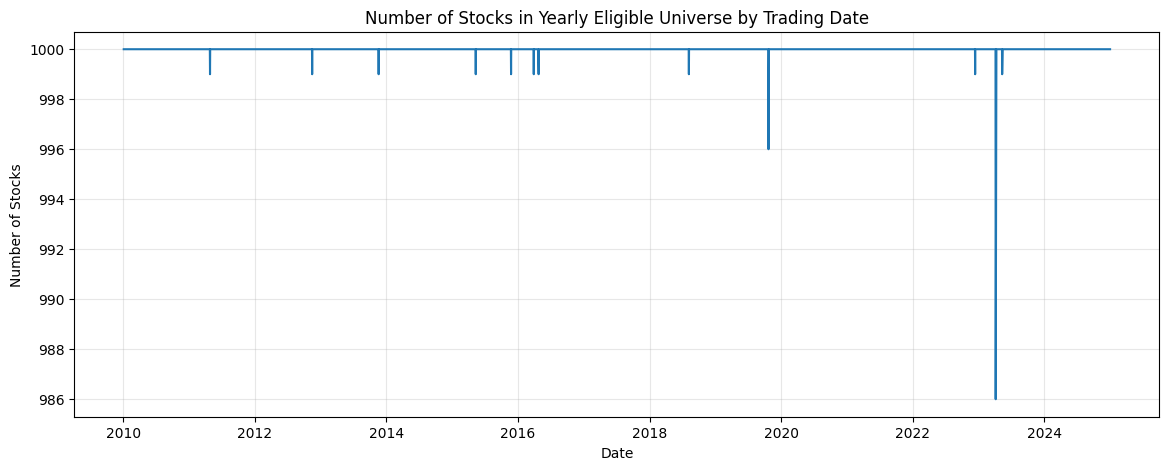

In [39]:
import matplotlib.pyplot as plt

df_universe["date"] = pd.to_datetime(df_universe["date"]).dt.normalize()

# 每個交易日的股票數量
daily_universe_count = (
    df_universe
    .groupby("date")["instrument_id"]
    .nunique()
    .rename("n_stocks")
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_universe_count["date"],
    daily_universe_count["n_stocks"]
)

plt.title("Number of Stocks in Yearly Eligible Universe by Trading Date")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# 每天實際出現在 df_universe 裡的股票集合
actual_ids_by_date = (
    df_universe
    .groupby("date")["instrument_id"]
    .apply(lambda x: set(x.astype(int)))
)

# 找出每天缺少哪些 eligible_dict 裡的股票
missing_records = []

for date, actual_ids in actual_ids_by_date.items():
    year = date.year
    expected_ids = set(map(int, eligible_dict.get(year, [])))
    
    missing_ids = expected_ids - actual_ids
    
    if len(missing_ids) > 0:
        for instrument_id in sorted(missing_ids):
            missing_records.append({
                "date": date,
                "year": year,
                "instrument_id": instrument_id,
            })

missing_eligible = pd.DataFrame(missing_records)

missing_eligible

,date,year,instrument_id
0,2011-04-28,2011,344
1,2012-11-15,2012,930
2,2013-11-19,2013,1072
3,2015-05-12,2015,344
4,2015-11-24,2015,1072
5,2016-03-29,2016,1055
6,2016-04-25,2016,821
7,2018-08-07,2018,1584
8,2019-10-23,2019,505
9,2019-10-23,2019,636


## Display NaN count by date

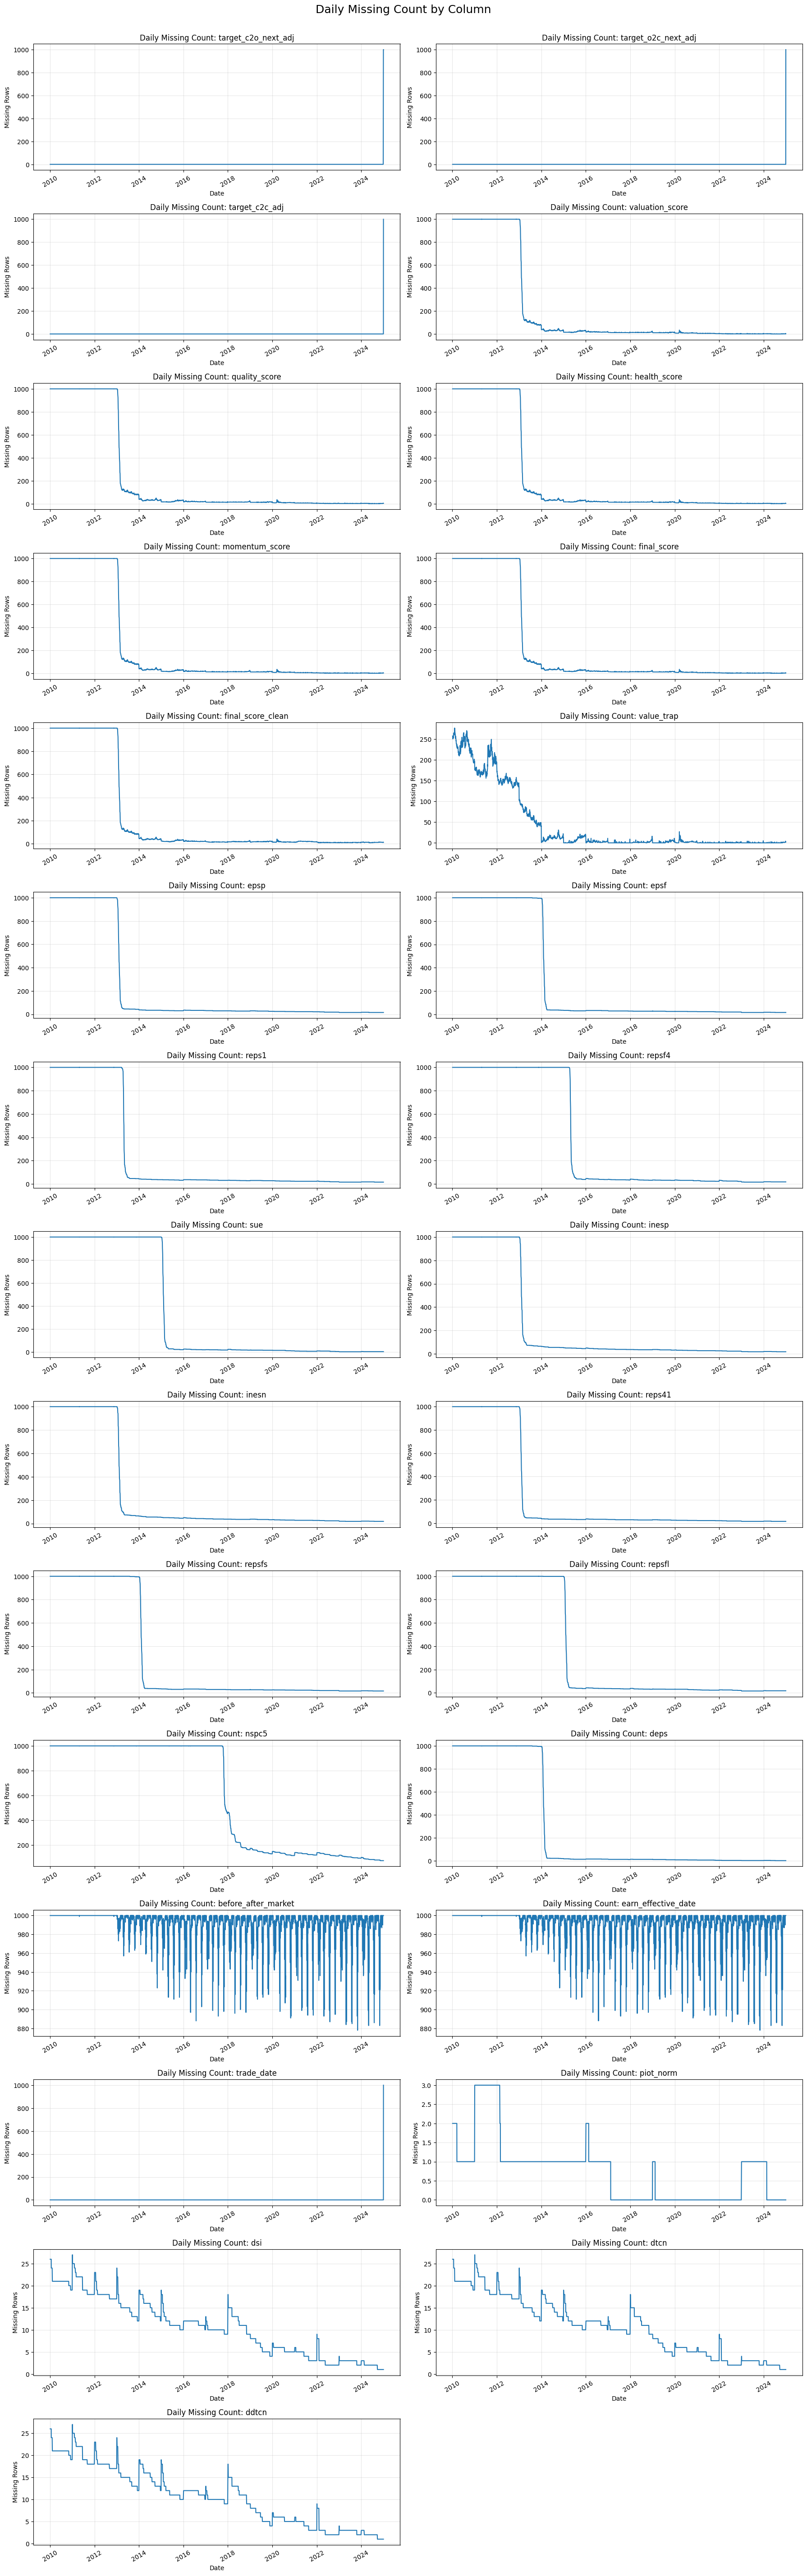

In [41]:
import math
import pandas as pd
import matplotlib.pyplot as plt

na_cols = df_universe.columns[df_universe.isna().any()].tolist()

daily_missing = (
    df_universe
    .groupby("date")[na_cols]
    .apply(lambda x: x.isna().sum())
    .reset_index()
)

n_cols = 2
n_rows = math.ceil(len(na_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 3.8 * n_rows),
    sharex=False   # 關鍵：不要共享 x 軸，讓每張都顯示時間
)

axes = axes.flatten()

for i, col in enumerate(na_cols):
    ax = axes[i]
    
    ax.plot(daily_missing["date"], daily_missing[col])
    ax.set_title(f"Daily Missing Count: {col}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Missing Rows")
    ax.grid(True, alpha=0.3)
    
    # 讓日期標籤不要擠在一起
    ax.tick_params(axis="x", labelrotation=30)

# 關掉多餘空圖
for j in range(len(na_cols), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Daily Missing Count by Column",
    fontsize=18,
    y=1.002
)

plt.tight_layout()
plt.show()

In [42]:
df_universe.columns


Index(['ticker', 'instrument_id', 'date', 'open', 'high', 'low', 'close',
       'volume', 'status', 'adj_factor', 'adjusted_open', 'adjusted_high',
       'adjusted_low', 'target_c2o_next_adj', 'target_o2c_next_adj',
       'target_c2c_adj', 'valuation_score', 'quality_score', 'health_score',
       'momentum_score', 'final_score', 'final_score_clean', 'value_trap',
       'market_cap', 'adjusted_close', 'gics_sector', 'gics_group',
       'gics_industry', 'gics_subindustry', 'epsp', 'epsf', 'reps1', 'repsf4',
       'sue', 'inesp', 'inesn', 'reps41', 'repsfs', 'repsfl', 'nspc5', 'deps',
       'before_after_market', 'prev_date', 'earn_effective_date', 'trade_date',
       'in_earn_window', 'piot_norm', 'dsi', 'dtcn', 'ddtcn', 'year',
       'in_yearly_universe'],
      dtype='object')

## Sanity Check

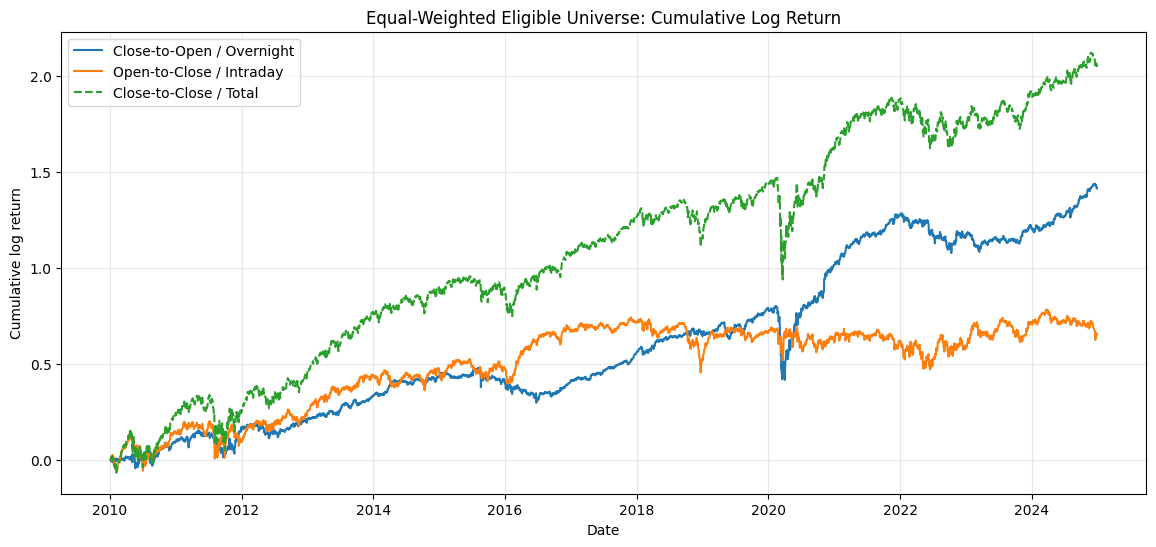

In [43]:
return_cols = ["target_c2o_next_adj", "target_o2c_next_adj", "target_c2c_adj"]

# 3. Equal-weighted daily returns
valid_mask = df_universe[return_cols].notna().all(axis=1)

daily_returns = (
    df_universe.loc[valid_mask]
    .groupby("date")
    .agg(
        n_stocks=("instrument_id", "nunique"),
        overnight=("target_c2o_next_adj", "mean"),
        intraday=("target_o2c_next_adj", "mean"),
        close_to_close=("target_c2c_adj", "mean"),
    )
    .reset_index()
    .sort_values("date")
)

# Cumulative log returns

daily_returns["cum_log_overnight"] = np.log1p(daily_returns["overnight"]).cumsum()
daily_returns["cum_log_intraday"] = np.log1p(daily_returns["intraday"]).cumsum()
daily_returns["cum_log_close_to_close"] = np.log1p(daily_returns["close_to_close"]).cumsum()

# ============================================================
# 5. Plot cumulative log return
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_returns["date"],
    daily_returns["cum_log_overnight"],
    label="Close-to-Open / Overnight"
)

plt.plot(
    daily_returns["date"],
    daily_returns["cum_log_intraday"],
    label="Open-to-Close / Intraday"
)

plt.plot(
    daily_returns["date"],
    daily_returns["cum_log_close_to_close"],
    label="Close-to-Close / Total",
    linestyle="--"
)

plt.title("Equal-Weighted Eligible Universe: Cumulative Log Return")
plt.xlabel("Date")
plt.ylabel("Cumulative log return")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [44]:
# 確保 date 是 datetime
daily_returns["date"] = pd.to_datetime(daily_returns["date"])
daily_returns["year"] = daily_returns["date"].dt.year

# 只保留 development window
daily_returns_dev = daily_returns[
    (daily_returns["year"] >= 2010) &
    (daily_returns["year"] <= 2024)
].copy()

# 每年 cumulative log return
yearly_log_returns = (
    daily_returns_dev
    .assign(
        C2O=np.log1p(daily_returns_dev["overnight"]),
        O2C=np.log1p(daily_returns_dev["intraday"]),
        C2C=np.log1p(daily_returns_dev["close_to_close"]),
    )
    .groupby("year")[["C2O", "O2C", "C2C"]]
    .sum()
)

# Component | Mean | Std | Min | Max
dispersion_table = (
    yearly_log_returns
    .agg(["mean", "std", "min", "max"])
    .T
    .rename(columns={
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "max": "Max",
    })
)

print("Yearly cumulative log returns:")
display(yearly_log_returns)

print("Dispersion table:")
display(dispersion_table)

Yearly cumulative log returns:


,C2O,O2C,C2C
year,,,
2010,0.101751,0.148587,0.245691
2011,0.063435,-0.054443,0.014863
2012,0.048895,0.160530,0.203570
2013,0.117938,0.181815,0.297603
2014,0.098777,0.023751,0.128603
2015,-0.027122,0.011811,-0.024995
2016,0.011769,0.196213,0.206429
2017,0.143802,0.047834,0.192826
2018,0.085102,-0.183628,-0.092007


Dispersion table:


,Mean,Std,Min,Max
C2O,0.094493,0.098302,-0.106551,0.264466
O2C,0.043735,0.110966,-0.183628,0.196213
C2C,0.136551,0.136868,-0.147178,0.297603


## Defining a capacity-aware universe

### Using columns

In [46]:
df = df[['instrument_id', 'date', 'open', 'high', 'low', 'close',
       'volume', 'adj_factor', 'adjusted_open', 'adjusted_high',
       'adjusted_low', 'adjusted_close', 'market_cap',
        'valuation_score', 'quality_score', 'health_score',
       'momentum_score', 'final_score', 'final_score_clean', 'value_trap',
       'gics_industry',
         'epsp', 'epsf', 'reps1', 'repsf4',
       'sue', 'inesp', 'inesn', 'reps41', 'repsfs', 'repsfl', 'deps',
       'piot_norm', 'in_earn_window',
         'dsi', 'dtcn', 'ddtcn', 'target_c2o_next_adj']]


### eligibility table

In [84]:
def build_eligibility_table(
    df_train: pd.DataFrame,
    eligible_dict: dict[int, list[int]],
    portfolio_aum: float,
    n_long: int = 100,
    n_short: int = 100,
    price_floor: float = 10.0,
    adv_multiple: float = 10.0,
    vol_window: int = 20,
    vol_floor: float = 0.05,
    vol_cap: float = 1.00,
    market_impact_k: float = 0.7,
) -> pd.DataFrame:
    """
    Build per-(stock, date) eligibility table using first-fail binding constraints.

    Filter order:
    1. MCAP_FAIL: not in year-start top 1000 universe
    2. PRICE_FAIL: close <= price_floor
    3. ADV_FAIL: ADV20 <= adv_multiple * per-stock target position
    4. VOL_FAIL: annualized 20-day realized volatility not in (vol_floor, vol_cap)
    5. EARN_WINDOW: in_earn_window == True
    6. OK: passes all filters

    Also computes implied participation rate and implied square-root impact slippage:
        f = per_stock_position / ADV20
        impact_bps = k * daily_vol * sqrt(f) * 1e4
    """

    df = df_train.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    df = df.sort_values(["instrument_id", "date"]).reset_index(drop=True)

    # -----------------------------
    # Per-stock target position
    # -----------------------------
    n_total_names = n_long + n_short
    per_stock_position = portfolio_aum / n_total_names

    # -----------------------------
    # Base universe membership
    # -----------------------------
    df["in_base_universe"] = False

    for year, ids in eligible_dict.items():
        year_mask = df["year"].eq(year)
        id_set = set(map(int, ids))
        df.loc[year_mask, "in_base_universe"] = (
            df.loc[year_mask, "instrument_id"].astype(int).isin(id_set)
        )

    # -----------------------------
    # Price filter
    # -----------------------------
    df["price_filter_pass"] = df["close"] > price_floor

    # -----------------------------
    # ADV20 filter
    # ADV20 = trailing 20-day mean of dollar volume
    # dollar volume = raw close * raw share volume
    # -----------------------------
    df["dollar_volume"] = df["close"] * df["volume"]

    df["adv20"] = (
        df.groupby("instrument_id")["dollar_volume"]
        .rolling(window=20, min_periods=20)
        .mean()
        .reset_index(level=0, drop=True)
    )

    adv_threshold = adv_multiple * per_stock_position

    df["adv_filter_pass"] = df["adv20"] > adv_threshold

    # -----------------------------
    # Realized volatility filter
    # annualized 20-day volatility from adjusted close-to-close returns
    # -----------------------------
    df["ret_cc_for_vol"] = (
        df.groupby("instrument_id")["adjusted_close"]
        .pct_change()
    )

    df["realized_vol_20d_daily"] = (
        df.groupby("instrument_id")["ret_cc_for_vol"]
        .rolling(window=vol_window, min_periods=vol_window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df["realized_vol_20d_ann"] = (
        df["realized_vol_20d_daily"] * np.sqrt(252)
    )

    df["vol_filter_pass"] = (
        (df["realized_vol_20d_ann"] > vol_floor)
        & (df["realized_vol_20d_ann"] < vol_cap)
    )

    # -----------------------------
    # Implied participation and slippage
    # -----------------------------
    df["implied_participation_rate"] = (
        per_stock_position / df["adv20"]
    )

    # invalid ADV gives NaN, not inf
    df.loc[
        ~np.isfinite(df["implied_participation_rate"]),
        "implied_participation_rate"
    ] = np.nan

    df["slippage_commission_bps"] = (
        market_impact_k
        * df["realized_vol_20d_daily"]
        * np.sqrt(df["implied_participation_rate"])
        * 1e4 + 0.5
    )

    # If participation is negative/impossible, set slippage to NaN
    df.loc[
        df["implied_participation_rate"].le(0)
        | df["implied_participation_rate"].isna(),
        "slippage_commission_bps"
    ] = np.nan

    # -----------------------------
    # Earnings window filter
    # -----------------------------
    if "in_earn_window" not in df.columns:
        raise ValueError("df_train must contain column 'in_earn_window'.")

    df["earn_filter_pass"] = ~df["in_earn_window"].fillna(False).astype(bool)

    # -----------------------------
    # First-fail binding constraint
    # -----------------------------
    df["eligibility_reason"] = "OK"

    df.loc[~df["in_base_universe"], "eligibility_reason"] = "MCAP_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["price_filter_pass"], "eligibility_reason"] = "PRICE_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["adv_filter_pass"], "eligibility_reason"] = "ADV_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["vol_filter_pass"], "eligibility_reason"] = "VOL_FAIL"

    ok = df["eligibility_reason"].eq("OK")
    df.loc[ok & ~df["earn_filter_pass"], "eligibility_reason"] = "EARN_WINDOW"

    df["is_eligible"] = df["eligibility_reason"].eq("OK")

    # -----------------------------
    # Useful output columns
    # -----------------------------
    output_cols = [
        "instrument_id",
        "ticker",
        "date",
        "year",
        "in_base_universe",
        "close",
        "adjusted_close",
        "volume",
        "dollar_volume",
        "adv20",
        "implied_participation_rate",
        "realized_vol_20d_daily",
        "realized_vol_20d_ann",
        "slippage_commission_bps",
        "in_earn_window",
        "eligibility_reason",
        "is_eligible",
    ]

    existing_output_cols = [c for c in output_cols if c in df.columns]

    eligibility_table = df[existing_output_cols].copy()

    eligibility_table.attrs["portfolio_aum"] = portfolio_aum
    eligibility_table.attrs["n_long"] = n_long
    eligibility_table.attrs["n_short"] = n_short
    eligibility_table.attrs["per_stock_position"] = per_stock_position
    eligibility_table.attrs["adv_threshold"] = adv_threshold
    eligibility_table.attrs["adv_multiple"] = adv_multiple
    eligibility_table.attrs["participation_cap_equivalent"] = 1 / adv_multiple
    eligibility_table.attrs["market_impact_k"] = market_impact_k

    return eligibility_table

In [107]:
eligibility_50m = build_eligibility_table(
    df_train=df,
    eligible_dict=eligible_dict,
    portfolio_aum=50_000_000,
)

eligibility_250m = build_eligibility_table(
    df_train=df,
    eligible_dict=eligible_dict,
    portfolio_aum=250_000_000,
)

eligibility_1b = build_eligibility_table(
    df_train=df,
    eligible_dict=eligible_dict,
    portfolio_aum=1_000_000_000,
)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_1944/2569965805.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["earn_filter_pass"] = ~df["in_earn_window"].fillna(False).astype(bool)
/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_1944/2569965805.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["earn_filter_pass"] = ~df["in_earn_window"].fillna(False).astype(bool)
/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_1944/2569965805.py:134: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfi

For Long 100 short 100, daily eligibble stock count after our filter:

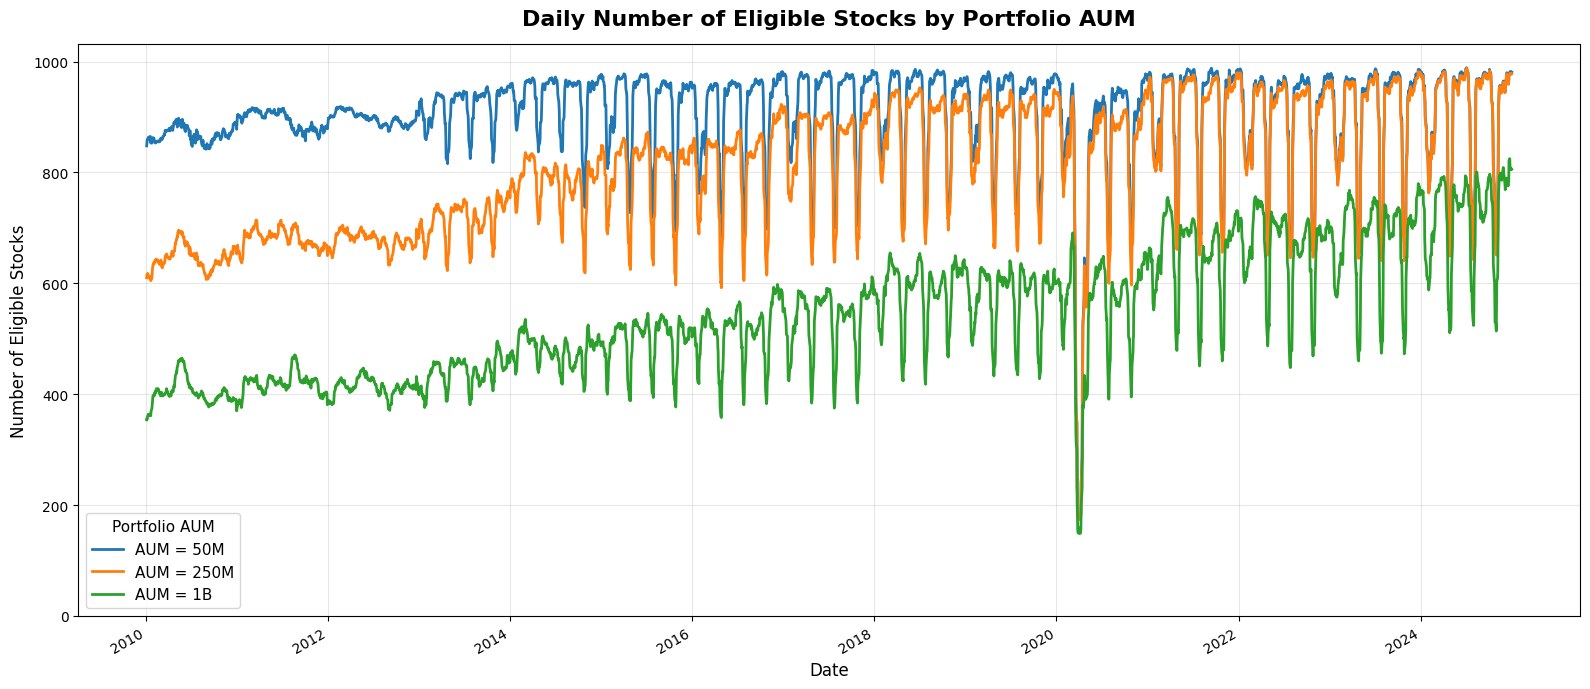

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_eligible_count_by_aum(
    eligibility_50m,
    eligibility_250m,
    eligibility_1b,
):
    # 建 daily eligible count
    s_50m = (
        eligibility_50m.loc[eligibility_50m["is_eligible"]]
        .groupby("date")
        .size()
        .rename("AUM = 50M")
    )

    s_250m = (
        eligibility_250m.loc[eligibility_250m["is_eligible"]]
        .groupby("date")
        .size()
        .rename("AUM = 250M")
    )

    s_1b = (
        eligibility_1b.loc[eligibility_1b["is_eligible"]]
        .groupby("date")
        .size()
        .rename("AUM = 1B")
    )

    counts = pd.concat([s_50m, s_250m, s_1b], axis=1).sort_index()
    counts.index = pd.to_datetime(counts.index)

    # Plot
    fig, ax = plt.subplots(figsize=(16, 7))

    counts.plot(ax=ax, linewidth=2.0)

    ax.set_title(
        "Daily Number of Eligible Stocks by Portfolio AUM",
        fontsize=16,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Number of Eligible Stocks", fontsize=12)

    ax.grid(True, alpha=0.3)
    ax.legend(title="Portfolio AUM", fontsize=11, title_fontsize=11)

    ax.set_ylim(bottom=0)

    plt.tight_layout()

    plt.show()

    return counts


eligible_count_by_aum = plot_eligible_count_by_aum(
    eligibility_50m=eligibility_50m,
    eligibility_250m=eligibility_250m,
    eligibility_1b=eligibility_1b,
)

In [102]:
from pathlib import Path

Path("figures").mkdir(parents=True, exist_ok=True)

def build_cost_distribution_df(
    eligibility_50m: pd.DataFrame,
    eligibility_250m: pd.DataFrame,
    eligibility_1b: pd.DataFrame,
    cost_col: str = "slippage_commission_bps",
    only_eligible: bool = True,
) -> pd.DataFrame:
    dfs = []

    inputs = {
        "50M": eligibility_50m,
        "250M": eligibility_250m,
        "1B": eligibility_1b,
    }

    for aum_label, df in inputs.items():
        temp = df.copy()

        if only_eligible:
            temp = temp.loc[temp["is_eligible"]].copy()

        temp = temp.loc[
            temp[cost_col].notna(),
            ["date", "instrument_id", "ticker", cost_col,
             "implied_participation_rate", "realized_vol_20d_daily", "adv20"]
            if "ticker" in temp.columns
            else ["date", "instrument_id", cost_col,
                  "implied_participation_rate", "realized_vol_20d_daily", "adv20"]
        ].copy()

        temp["AUM"] = aum_label
        dfs.append(temp)

    out = pd.concat(dfs, ignore_index=True)
    out["date"] = pd.to_datetime(out["date"])

    return out


cost_dist_df = build_cost_distribution_df(
    eligibility_50m=eligibility_50m,
    eligibility_250m=eligibility_250m,
    eligibility_1b=eligibility_1b,
    cost_col="slippage_commission_bps",
    only_eligible=True,
)

### Estimate slippage **\(Different from the slides\)**

- 他應該是說要用ADV篩掉一些股票，因為如果我要打入一檔股票的金額占據ADV的百分比越大，我會預期有著更高的滑價，所以應該篩掉限制我打很大的部位進一個小ADV的股票（流動性差）
- 啊這樣他後面又說用固定的slippage我覺得很莫名其妙
- 我改成 “決定最大可忍受之預期滑價” 然後超過就判斷為 not eligible (ADV_FAIL)
- 並且在容忍範圍內，會計算他預期滑價，而不是用老師說的的固定滑價

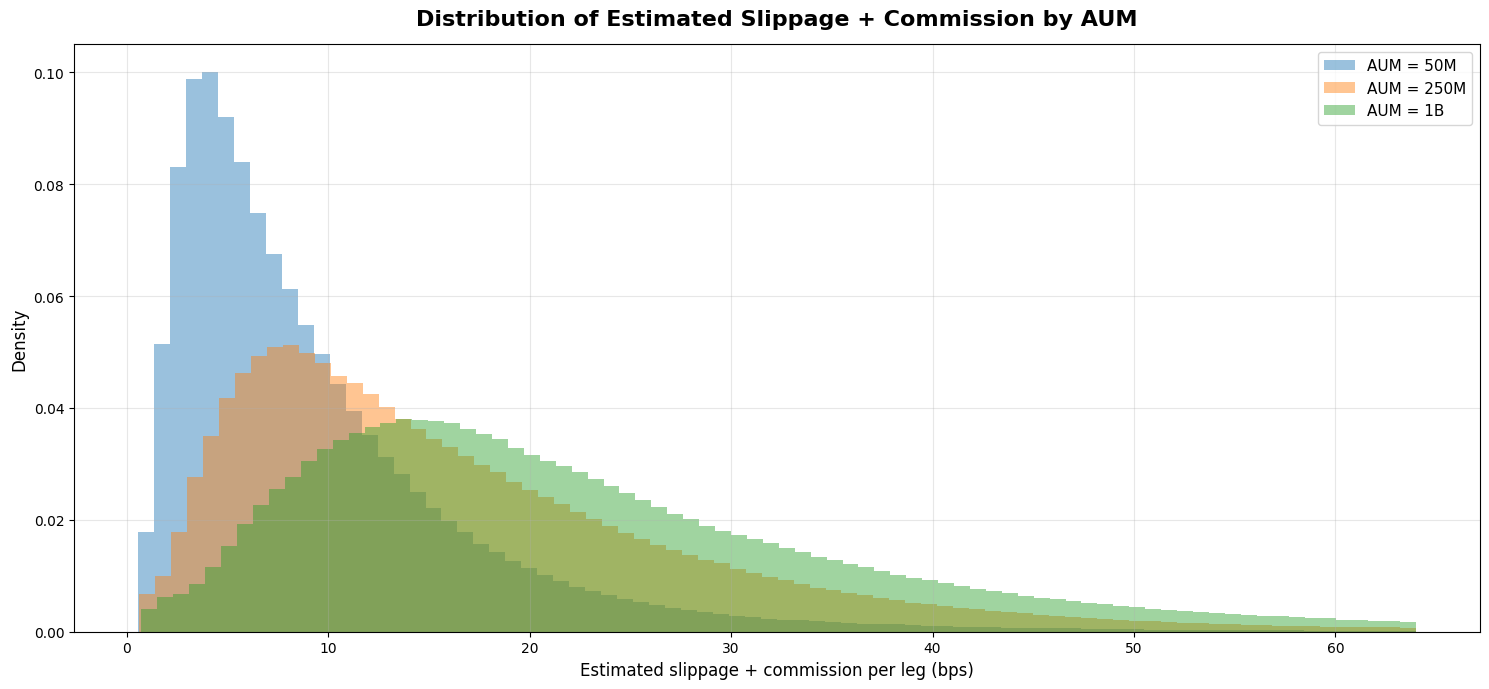

In [103]:
def plot_cost_histogram(
    cost_dist_df: pd.DataFrame,
    cost_col: str = "slippage_commission_bps",
    save_path: str = "figures/slippage_commission_distribution_hist.png",
    upper_quantile: float = 0.99,
):
    plot_df = cost_dist_df.copy()

    # 為了避免極端值把圖拉爆，只畫到 pooled 99% quantile
    x_max = plot_df[cost_col].quantile(upper_quantile)
    plot_df = plot_df[plot_df[cost_col] <= x_max].copy()

    fig, ax = plt.subplots(figsize=(15, 7))

    for aum_label in ["50M", "250M", "1B"]:
        x = plot_df.loc[plot_df["AUM"].eq(aum_label), cost_col].dropna()
        ax.hist(
            x,
            bins=80,
            alpha=0.45,
            density=True,
            label=f"AUM = {aum_label}",
        )

    ax.set_title(
        "Distribution of Estimated Slippage + Commission by AUM",
        fontsize=16,
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("Estimated slippage + commission per leg (bps)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_cost_histogram(cost_dist_df)

In [104]:
def binding_constraint_distribution(eligibility_table: pd.DataFrame) -> pd.DataFrame:
    dist = (
        eligibility_table
        .groupby(["year", "eligibility_reason"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    reason_order = [
        "year",
        "OK",
        "MCAP_FAIL",
        "PRICE_FAIL",
        "ADV_FAIL",
        "VOL_FAIL",
        "EARN_WINDOW",
    ]

    cols = [c for c in reason_order if c in dist.columns]
    other_cols = [c for c in dist.columns if c not in cols]

    return dist[cols + other_cols]


dist_50m = binding_constraint_distribution(eligibility_50m)
dist_250m = binding_constraint_distribution(eligibility_250m)
dist_1b = binding_constraint_distribution(eligibility_1b)

display(dist_50m)
display(dist_250m)
display(dist_1b)

eligibility_reason,year,OK,MCAP_FAIL,PRICE_FAIL,ADV_FAIL,VOL_FAIL,EARN_WINDOW
0,2000,0,232361,0,0,0,0
1,2001,0,233287,0,0,0,0
2,2002,0,243320,0,0,0,0
3,2003,0,247573,0,0,0,0
4,2004,0,254999,0,0,0,0
5,2005,0,262648,0,0,0,0
6,2006,0,267958,0,0,0,0
7,2007,0,276855,0,0,0,0
8,2008,0,285222,0,0,0,0
9,2009,0,286901,0,0,0,0


eligibility_reason,year,OK,MCAP_FAIL,PRICE_FAIL,ADV_FAIL,VOL_FAIL,EARN_WINDOW
0,2000,0,232361,0,0,0,0
1,2001,0,233287,0,0,0,0
2,2002,0,243320,0,0,0,0
3,2003,0,247573,0,0,0,0
4,2004,0,254999,0,0,0,0
5,2005,0,262648,0,0,0,0
6,2006,0,267958,0,0,0,0
7,2007,0,276855,0,0,0,0
8,2008,0,285222,0,0,0,0
9,2009,0,286901,0,0,0,0


eligibility_reason,year,OK,MCAP_FAIL,PRICE_FAIL,ADV_FAIL,VOL_FAIL,EARN_WINDOW
0,2000,0,232361,0,0,0,0
1,2001,0,233287,0,0,0,0
2,2002,0,243320,0,0,0,0
3,2003,0,247573,0,0,0,0
4,2004,0,254999,0,0,0,0
5,2005,0,262648,0,0,0,0
6,2006,0,267958,0,0,0,0
7,2007,0,276855,0,0,0,0
8,2008,0,285222,0,0,0,0
9,2009,0,286901,0,0,0,0


## Q: What participation cap do you assume in the closing auction, and what is the implied slippage at that cap for a typical mid-cap and a typical large-cap name in your universe?

In [108]:
import numpy as np
import pandas as pd

def compute_cap_level_slippage_examples(
    eligibility_table: pd.DataFrame,
    annual_universe_table: pd.DataFrame,
    participation_cap: float = 0.10,
    k: float = 0.7,
) -> pd.DataFrame:
    """
    Compute implied one-way square-root impact at participation cap
    for large-cap and lower-cap buckets within the top-1000 universe.
    """

    df = eligibility_table.copy()
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year

    ranks = annual_universe_table[
        ["universe_year", "instrument_id", "rank_mcap"]
    ].copy()

    ranks = ranks.rename(columns={"universe_year": "year"})

    df = df.merge(
        ranks,
        how="left",
        on=["year", "instrument_id"],
        validate="m:1"
    )

    # Use only rows that pass all eligibility filters
    df = df[df["is_eligible"]].copy()

    # Define buckets inside the annual top-1000 universe
    conditions = [
        df["rank_mcap"].between(1, 250),
        df["rank_mcap"].between(751, 1000),
    ]

    choices = [
        "Large-cap bucket: rank 1-250",
        "Lower-cap bucket: rank 751-1000",
    ]

    df["bucket"] = np.select(conditions, choices, default=np.nan)
    df = df[df["bucket"].notna()].copy()

    # Daily volatility from annualized volatility
    df["sigma_daily"] = df["realized_vol_20d_ann"] / np.sqrt(252)

    # Cap-level implied impact in bps
    df["impact_bps_at_cap"] = (
        k
        * df["sigma_daily"]
        * np.sqrt(participation_cap)
        * 1e4
    )

    summary = (
        df.groupby("bucket")
        .agg(
            median_annualized_vol=("realized_vol_20d_ann", "median"),
            median_daily_vol=("sigma_daily", "median"),
            implied_slippage_bps_at_10pct_adv=("impact_bps_at_cap", "median"),
            median_adv20=("adv20", "median"),
            n_stock_days=("instrument_id", "size"),
        )
        .reset_index()
    )

    return summary


slippage_examples_250m = compute_cap_level_slippage_examples(
    eligibility_table=eligibility_250m,
    annual_universe_table=eligible_table,
    participation_cap=0.10,
    k=0.7,
)

slippage_examples_250m

,bucket,median_annualized_vol,median_daily_vol,implied_slippage_bps_at_10pct_adv,median_adv20,n_stock_days
0,Large-cap bucket: rank 1-250,0.218687,0.013776,30.494439,2.979369e+08,884036
1,Lower-cap bucket: rank 751-1000,0.304505,0.019182,42.461244,2.721834e+07,530513
2,nan,0.254713,0.016045,35.517993,7.101198e+07,1631019


In [109]:
eligibility_50m = eligibility_50m[['instrument_id', 'date', 'slippage_commission_bps', 'eligibility_reason', 'is_eligible']].dropna(subset='slippage_commission_bps').reset_index(drop=True)
eligibility_250m = eligibility_250m[['instrument_id', 'date', 'slippage_commission_bps', 'eligibility_reason', 'is_eligible']].dropna(subset='slippage_commission_bps').reset_index(drop=True)
eligibility_1b = eligibility_1b[['instrument_id', 'date', 'slippage_commission_bps', 'eligibility_reason', 'is_eligible']].dropna(subset='slippage_commission_bps').reset_index(drop=True)

eligibility_50m.to_parquet('data/eligibility_50m.parquet')
eligibility_250m.to_parquet('data/eligibility_250m.parquet')
eligibility_1b.to_parquet('data/eligibility_1b.parquet')

## Filtering the short leg for borrow cost

In [110]:
import numpy as np
import pandas as pd


def add_hard_to_borrow_proxy(
    df: pd.DataFrame,
    short_cols: list[str] = ["dsi", "dtcn", "ddtcn"],
    tier_b_threshold: float = 0.70,
    tier_c_threshold: float = 0.90,
    dsi_override_threshold: float = 0.95,
    dtcn_override_threshold: float = 0.8,
) -> pd.DataFrame:

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["date", "instrument_id"]).reset_index(drop=True)

    missing_cols = [c for c in short_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing short-interest columns: {missing_cols}")

    # -----------------------------
    # Cross-sectional percentile ranks by date
    # -----------------------------
    for col in short_cols:
        rank_col = f"{col}_rank_pct"

        df[rank_col] = (
            df.groupby("date")[col]
            .rank(method="average", pct=True)
        )

        df[rank_col] = df[rank_col].fillna(0.0)

    # -----------------------------
    # Weighted hard-to-borrow score
    # -----------------------------
    df["htb_score"] = (
        0.45 * df["dsi_rank_pct"]
        + 0.35 * df["dtcn_rank_pct"]
        + 0.20 * df["ddtcn_rank_pct"]
    )

    # -----------------------------
    # Base tier assignment
    # -----------------------------
    df["borrow_tier"] = "A"

    df.loc[
        (df["htb_score"] >= tier_b_threshold)
        & (df["htb_score"] < tier_c_threshold),
        "borrow_tier"
    ] = "B"

    df.loc[
        df["htb_score"] >= tier_c_threshold,
        "borrow_tier"
    ] = "C"

    # -----------------------------
    # Extreme short-interest override
    # -----------------------------
    extreme_level_mask = (
        (df["dsi_rank_pct"] >= dsi_override_threshold)
        & (df["dtcn_rank_pct"] >= dtcn_override_threshold)
    )

    df.loc[extreme_level_mask, "borrow_tier"] = "C"

    # -----------------------------
    # Borrow rates
    # -----------------------------
    borrow_rate_map = {
        "A": 0.0040,  # 40 bps p.a.
        "B": 0.0200,  # 200 bps p.a.
        "C": 0.0800,  # 800 bps p.a.
    }

    df["borrow_rate_pa"] = df["borrow_tier"].map(borrow_rate_map)
    df["borrow_rate_daily"] = df["borrow_rate_pa"] / 252

    df["is_hard_to_borrow_moderate"] = df["borrow_tier"].isin(["B", "C"])
    df["is_hard_to_borrow_high"] = df["borrow_tier"].eq("C")

    return df

### 1000 universe df -> CS rank the hard borrow proxy
Using yearly 1000 universe -> use "dsi", "dtcn", "ddtcn", get a weighted score
Using Rank(weighted score) to determine its hard to borrow level

In [127]:
df_hardtoborrow = add_hard_to_borrow_proxy(df_universe)


tier_dist = (
    df_hardtoborrow
    .groupby("borrow_tier")
    .size()
    .rename("stock_days")
    .reset_index()
)

tier_dist["fraction"] = tier_dist["stock_days"] / tier_dist["stock_days"].sum()

tier_dist

,borrow_tier,stock_days,fraction
0,A,2891056,0.766051
1,B,655523,0.173696
2,C,227392,0.060253


In [128]:
df_hardtoborrow["year"] = df_hardtoborrow["date"].dt.year

tier_dist_by_year = (
    df_hardtoborrow
    .groupby(["year", "borrow_tier"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

tier_dist_by_year_2010_2024 = tier_dist_by_year[
    (tier_dist_by_year["year"] >= 2010)
    & (tier_dist_by_year["year"] <= 2024)
].copy()

tier_dist_by_year_2010_2024

borrow_tier,year,A,B,C
0,2010,193391,44802,13807
1,2011,194363,44088,13548
2,2012,192471,43548,13980
3,2013,192474,42366,17159
4,2014,192967,42955,16078
5,2015,192137,44290,15571
6,2016,192249,45083,14666
7,2017,191110,44033,15857
8,2018,192003,43369,15627
9,2019,191422,44444,16129


In [ ]:
import pandas as pd

def inspect_borrow_proxy_event(
    df: pd.DataFrame,
    ticker: str,
    start: str,
    end: str,
) -> pd.DataFrame:
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])

    cols = [
        "date",
        "instrument_id",
        "dsi",
        "dtcn",
        "ddtcn",
        "dsi_rank_pct",
        "dtcn_rank_pct",
        "ddtcn_rank_pct",
        "htb_score",
        "borrow_tier",
        "borrow_rate_pa",
        "is_eligible"
    ]

    cols = [c for c in cols if c in out.columns]

    event = (
        out.loc[
            out["instrument_id"].eq(ticker)
            & out["date"].between(pd.to_datetime(start), pd.to_datetime(end)),
            cols
        ]
        .sort_values("date")
        .copy()
    )

    return event


tsla_event = inspect_borrow_proxy_event(
    df_hardtoborrow,
    ticker=123,
    start="2021-02-10",
    end="2021-03-10",
)

tsla_event#[tsla_event['borrow_tier']!='A']

,date,instrument_id,dsi,dtcn,ddtcn,dsi_rank_pct,dtcn_rank_pct,ddtcn_rank_pct,htb_score,borrow_tier,borrow_rate_pa
2795107,2021-02-10,123,0.059466,1.862199,0.604149,0.860302,0.194975,0.825126,0.620402,A,0.004
2796107,2021-02-11,123,0.059466,1.862199,0.604149,0.860302,0.194975,0.825126,0.620402,A,0.004
2797107,2021-02-12,123,0.059466,1.862199,0.604149,0.860302,0.194975,0.825126,0.620402,A,0.004
2798107,2021-02-16,123,0.059466,1.862199,0.604149,0.860302,0.194975,0.825126,0.620402,A,0.004
2799107,2021-02-17,123,0.059466,1.862199,0.604149,0.860302,0.194975,0.825126,0.620402,A,0.004
2800107,2021-02-18,123,0.059466,1.862199,0.604149,0.860302,0.194975,0.825126,0.620402,A,0.004
2801107,2021-02-19,123,0.054570,2.312746,1.505595,0.855276,0.419095,0.915578,0.714673,B,0.020
2802107,2021-02-22,123,0.054570,2.312746,1.505595,0.855276,0.419095,0.915578,0.714673,B,0.020
2803107,2021-02-23,123,0.054570,2.312746,1.505595,0.855276,0.419095,0.915578,0.714673,B,0.020
2804107,2021-02-24,123,0.054570,2.312746,1.505595,0.855276,0.419095,0.915578,0.714673,B,0.020


In [146]:
df_hardtoborrow.columns

Index(['ticker', 'instrument_id', 'date', 'open', 'high', 'low', 'close',
       'volume', 'status', 'adj_factor', 'adjusted_open', 'adjusted_high',
       'adjusted_low', 'target_c2o_next_adj', 'target_o2c_next_adj',
       'target_c2c_adj', 'valuation_score', 'quality_score', 'health_score',
       'momentum_score', 'final_score', 'final_score_clean', 'value_trap',
       'market_cap', 'adjusted_close', 'gics_sector', 'gics_group',
       'gics_industry', 'gics_subindustry', 'epsp', 'epsf', 'reps1', 'repsf4',
       'sue', 'inesp', 'inesn', 'reps41', 'repsfs', 'repsfl', 'nspc5', 'deps',
       'before_after_market', 'prev_date', 'earn_effective_date', 'trade_date',
       'in_earn_window', 'piot_norm', 'dsi', 'dtcn', 'ddtcn', 'year',
       'in_yearly_universe', 'dsi_rank_pct', 'dtcn_rank_pct', 'ddtcn_rank_pct',
       'htb_score', 'borrow_tier', 'borrow_rate_pa', 'borrow_rate_daily',
       'is_hard_to_borrow_moderate', 'is_hard_to_borrow_high'],
      dtype='object')

In [ ]:
df_hardtoborrow[
    ['instrument_id', 'date', 'dsi_rank_pct', 'dtcn_rank_pct', 'ddtcn_rank_pct',
       'htb_score', 'borrow_tier', 'borrow_rate_pa', 'borrow_rate_daily']
].to_parquet('data/df_hardtoborrow.parquet')

: 

## Feature Engineering

In [132]:
def get_monthly_factor_mining_data(
    df: pd.DataFrame,
    target_year: int,
    target_month: int,
    symbol_col: str = "instrument_id",
    time_col: str = "date",
    pool_dict: dict = None,
    lookback_months: int = 37,
) -> pd.DataFrame:

    if target_month < 1 or target_month > 12:
        raise ValueError("target_month 必須介於 1 到 12")

    if target_year not in pool_dict:
        raise ValueError(f"pool_dict 中找不到 target_year={target_year}")

    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col])
    out = out.sort_values([symbol_col, time_col]).reset_index(drop=True)

    target_month_start = pd.Timestamp(year=target_year, month=target_month, day=1)
    start_month = target_month_start - pd.DateOffset(months=lookback_months)

    out = out[
        (out[time_col] >= start_month) &
        (out[time_col] <= pd.Timestamp(year=target_year, month=12, day=31)) &
        (out[symbol_col].isin(pool_dict[target_year]))
    ].reset_index(drop=True)

    
    return out



### Make Yearly universe data and Merge them
- Every universe -> look back 37 months, since we want to use past data to calculate some price-volume factors
- e.g. for 2024 df_tem, we have 2021~2024 data for the 2024 universe stocks

In [133]:
all_dfs = []

for y in range(2010, 2025):
    df_tem = get_monthly_factor_mining_data(
        df=df,
        target_year=y,
        target_month=1,
        pool_dict=eligible_dict,
        lookback_months=37
    )
    all_dfs.append(df_tem)

df_all = (
    pd.concat(all_dfs, axis=0, ignore_index=True)
    .drop_duplicates(subset=["instrument_id", "date"], keep="last")
    .reset_index(drop=True)
)
df_all

,instrument_id,date,open,high,low,close,volume,adj_factor,adjusted_open,adjusted_high,...,reps41,repsfs,repsfl,deps,piot_norm,in_earn_window,dsi,dtcn,ddtcn,target_c2o_next_adj
0,2,2006-12-01,22.96,22.990,22.72,22.85,1409800.0,0.494394,11.351283,11.366115,...,NaN,NaN,NaN,NaN,0.666667,False,0.049905,14.902026,4.577381,-0.002178
1,2,2006-12-04,22.88,23.010,22.84,23.00,1585100.0,0.494396,11.311773,11.376044,...,NaN,NaN,NaN,NaN,0.666667,False,0.049905,14.902026,4.577381,-0.002604
2,2,2006-12-05,22.95,23.010,22.87,23.01,1603900.0,0.494394,11.346336,11.376000,...,NaN,NaN,NaN,NaN,0.666667,False,0.049905,14.902026,4.577381,0.001742
3,2,2006-12-06,22.95,22.990,22.87,22.91,1457300.0,0.494395,11.346376,11.366152,...,NaN,NaN,NaN,NaN,0.666667,False,0.049905,14.902026,4.577381,0.000440
4,2,2006-12-07,22.95,23.070,22.83,22.92,1698700.0,0.494394,11.346332,11.405659,...,NaN,NaN,NaN,NaN,0.666667,False,0.059113,20.196406,8.988666,0.001754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911311,1605,2024-12-24,118.53,119.565,117.96,118.74,1725800.0,0.998341,118.333348,119.366631,...,-0.001846,-0.000430,-0.004045,0.0132,0.888889,False,0.040405,2.241569,0.420790,-0.015228
4911312,1605,2024-12-26,118.00,120.100,117.77,118.88,2188900.0,0.998343,117.804458,119.900978,...,-0.001846,-0.000438,-0.004053,0.0132,0.888889,False,0.040405,2.241569,0.420790,-0.024153
4911313,1605,2024-12-27,117.07,118.000,113.48,115.11,3813100.0,0.998341,116.875748,117.804205,...,-0.001846,-0.000209,-0.003825,0.0132,0.888889,False,0.040405,2.241569,0.420790,0.001978
4911314,1605,2024-12-30,112.33,118.200,112.23,116.16,3663200.0,0.998338,112.143364,118.003611,...,-0.001846,-0.000275,-0.003890,0.0132,0.888889,False,0.040405,2.241569,0.420790,NaN


In [134]:
def basic_price_volume_features(df, ns = [1, 5, 20]):   

    df = df.copy()
    
    for n in ns:
        df[f"return_{n}"] = (
            df.groupby("instrument_id")["close"]
            .pct_change(n)
        )
    

    df["overnight_return"] = (
        df.groupby("instrument_id")["open"].shift(-1)
        / df["close"]
        - 1
    )

    df["ret_std_20"] = (
        df.groupby("instrument_id")["return_1"]
        .transform(lambda x: x.rolling(20, min_periods=20).std())
    )

    df["on_ret_std_20"] = (
        df.groupby("instrument_id")["overnight_return"]
        .transform(lambda x: x.rolling(20, min_periods=20).std())
    )

    df["range_pct"] = (
        (df["high"] - df["low"]) / df["close"]
    )

    df["estimate_turnover"] = (
        (df["high"] + df["low"] + df["close"]) / 3
        * df["volume"]
    )

    df["twr_num"] = df["estimate_turnover"] * df["return_1"]

    df["twr_20"] = (
        df.groupby("instrument_id")["twr_num"]
        .transform(lambda x: x.rolling(20, min_periods=20).sum())
        /
        df.groupby("instrument_id")["estimate_turnover"]
        .transform(lambda x: x.rolling(20, min_periods=20).sum())
    )

    df["volume_z_20"] = (
        df.groupby("instrument_id")["volume"]
        .transform(
            lambda x: (
                (x - x.rolling(20, min_periods=20).mean())
                / x.rolling(20, min_periods=20).std()
            )
        )
    )

    df["high_20"] = (
        df.groupby("instrument_id")["high"]
        .transform(lambda x: x.rolling(20, min_periods=20).max())
    )

    df["low_20"] = (
        df.groupby("instrument_id")["low"]
        .transform(lambda x: x.rolling(20, min_periods=20).min())
    )

    df["dist_to_high_20"] = df["close"] / df["high_20"] - 1
    df["dist_to_low_20"] = df["close"] / df["low_20"] - 1

    df["channel_pos_20"] = (
        (df["close"] - df["low_20"])
        / (df["high_20"] - df["low_20"])
    )
    df = df.drop(columns=["twr_num", "high_20", "low_20"])
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

In [135]:
df_all = basic_price_volume_features(df_all)

/var/folders/yb/8ggp9gv52cb8_8xlnpwq7qz40000gn/T/ipykernel_1944/514042006.py:75: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan)


In [136]:
import talib

def add_talib_features(
    df,
    periods=[5, 20],
    x_cols=[
        "open", "high", "low", "close", "volume",
    ],
    date_col="date",
    instrument_col="instrument_id"
):

    out = df.copy()

    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values([instrument_col, date_col]).reset_index(drop=True)

    x_cols = [c for c in x_cols if c in out.columns]

    feature_dfs = []

    for inst, g in out.groupby(instrument_col, sort=False):
        g = g.sort_values(date_col).copy()

        feat_dict = {}

        high = (
            g["high"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )

        low = (
            g["low"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )

        close = (
            g["close"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )

        volume = (
            g["volume"]
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .to_numpy()
        )


        # X-based indicators
        for x_col in x_cols:
            x = (
                g[x_col]
                .astype(float)
                .replace([np.inf, -np.inf], np.nan)
                .to_numpy()
            )

            for d in periods:
                feat_dict[f"DEMA_{x_col}_{d}"] = talib.DEMA(x, timeperiod=d)
                feat_dict[f"KAMA_{x_col}_{d}"] = talib.KAMA(x, timeperiod=d)
                feat_dict[f"MIDPOINT_{x_col}_{d}"] = talib.MIDPOINT(x, timeperiod=d)
                feat_dict[f"LINEARREG_SLOPE_{x_col}_{d}"] = talib.LINEARREG_SLOPE(
                    x,
                    timeperiod=d
                )


            try:
                feat_dict[f"HT_DCPHASE_{x_col}"] = talib.HT_DCPHASE(x)
            except Exception:
                feat_dict[f"HT_DCPHASE_{x_col}"] = np.full(len(g), np.nan)

        # --------------------------------------------------------
        # OHLCV-based indicators
        # --------------------------------------------------------
        for d in periods:
            feat_dict[f"WILLR_{d}"] = talib.WILLR(
                high,
                low,
                close,
                timeperiod=d
            )

            feat_dict[f"CCI_{d}"] = talib.CCI(
                high,
                low,
                close,
                timeperiod=d
            )

            feat_dict[f"ADX_{d}"] = talib.ADX(
                high,
                low,
                close,
                timeperiod=d
            )

            feat_dict[f"NATR_{d}"] = talib.NATR(
                high,
                low,
                close,
                timeperiod=d
            )

        feat = pd.DataFrame(feat_dict, index=g.index)
        feature_dfs.append(feat)

    feature_df = pd.concat(feature_dfs, axis=0).sort_index()

    out = pd.concat([out, feature_df], axis=1)

    # de-fragment dataframe
    out = out.copy()

    return out

In [137]:
df_featured = add_talib_features(df_all)


<Axes: xlabel='date'>

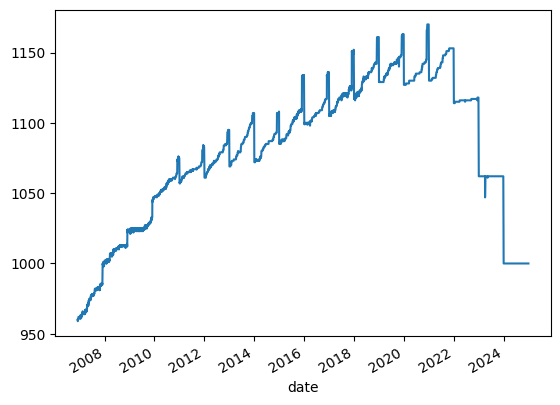

In [139]:
df_featured.groupby('date').size().plot()

In [145]:
df_featured.dropna(subset='target_c2o_next_adj').to_parquet('data/df_featured.parquet')
